In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, shapiro, chi2_contingency, ttest_ind, mannwhitneyu, spearmanr, f_oneway, kruskal
import warnings

warnings.filterwarnings('ignore')

In [253]:
df = pd.read_csv(r"C:\Users\User\Desktop\ecom_yl.csv")

# **Предобработка данных**


Сразу же приведем названия столбцов к нужному формату и приведем все нужные столбцы к формату datetime

In [254]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['session_start'] = pd.to_datetime(df['session_start'])
df['session_end'] = pd.to_datetime(df['session_end'])
df['session_date'] = pd.to_datetime(df['session_date'])
df['order_dt'] = pd.to_datetime(df['order_dt'])

In [255]:
df.head(5)

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.0,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.0,2019-05-01,5,3,7,NaT,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.0,2019-05-01,5,3,4,NaT,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.0,2019-05-01,5,3,18,NaT,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.0,2019-05-02,5,4,14,NaT,NaN,NaN,NaN


In [256]:
(df.isna().mean() * 100).to_frame()

,0
user_id,0.000000
region,1.284585
device,1.284585
channel,1.284585
session_start,0.000000
session_end,0.000000
sessiondurationsec,0.000000
session_date,0.000000
month,0.000000
day,0.000000


Замечаем что есть одинаковое количество пропусков в столбцах региона, устройства и рекламного канала. Мы проигнорируем пропуски в столбцах связанные с покупкой т.к это необязательные данные ведь не каждый пользователь при заходе на сайт совершает покупку.

In [257]:
print(df[df[['region', 'device', 'channel']].isna().any(axis=1)][['region', 'device', 'channel']])

    region device channel
303    NaN    NaN     NaN
392    NaN    NaN     NaN
429    NaN    NaN     NaN
547    NaN    NaN     NaN
549    NaN    NaN     NaN
564    NaN    NaN     NaN
599    NaN    NaN     NaN
600    NaN    NaN     NaN
652    NaN    NaN     NaN
686    NaN    NaN     NaN
918    NaN    NaN     NaN
925    NaN    NaN     NaN
935    NaN    NaN     NaN


Здесь мы замечаем что присутствует 13 строк с абсолютно пустыми значениями в столбцах региона устройства и рекламного канала. 
Наша команда решила происследовать исходят ли эти строки из второго захода на сайт одного и того же пользователя

In [258]:
duplicates = df[df.duplicated('user_id', keep=False)]
second_user_entries = duplicates.drop_duplicates('user_id', keep='last')
print(second_user_entries[['region', 'device', 'channel', 'session_date']])

            region   device             channel session_date
68   Unjted States   iPhone  реклама у блогеров   2019-05-17
196  Unjted States  Android     социальные сети   2019-06-11
303            NaN      NaN                 NaN   2019-07-01
392            NaN      NaN                 NaN   2019-07-20
429            NaN      NaN                 NaN   2019-07-28
547            NaN      NaN                 NaN   2019-08-16
549            NaN      NaN                 NaN   2019-08-16
564            NaN      NaN                 NaN   2019-08-18
600            NaN      NaN                 NaN   2019-08-25
652            NaN      NaN                 NaN   2019-09-03
686            NaN      NaN                 NaN   2019-09-10
918            NaN      NaN                 NaN   2019-10-14
925            NaN      NaN                 NaN   2019-10-15
935            NaN      NaN                 NaN   2019-10-17


В ходе этого наша команда выявила критическую проблему в системе сбора данных. Начиная с 1 июля наблюдается систематический сбой: при повторных заходах пользователей (начиная со второго визита) в базу данных перестают записываться такие ключевые параметры, как регион, тип устройства и рекламный канал. Возможно, база данных игнорирует сбор данных так как уже присутствует информация об этом пользователе. Этот инсайд указывает на потенциальный сбой в механизме обработки данных возвращающихся пользователей.

Примечательно, что еще до обозначенной даты в данных прослеживались тревожные сигналы - например, некорректные записи вроде "Unjted States" вместо правильного "United States", что свидетельствует о  сбоях в  записи данных при повторном заходе пользователя.

In [259]:
missing_df = df[df[['region', 'device', 'channel']].isna().any(axis=1)]
for i in missing_df.user_id:
    print(df[df['user_id'] == i][['user_id', 'region', 'device', 'channel']])

          user_id         region   device          channel
300  434852403169  United States  Android  социальные сети
303  434852403169            NaN      NaN              NaN
          user_id         region device          channel
333  213468351687  United States    Mac  социальные сети
392  213468351687            NaN    NaN              NaN
          user_id         region device             channel
165  679176482300  United States    Mac  реклама у блогеров
429  679176482300            NaN    NaN                 NaN
         user_id region device              channel
286  87458247642     UK    Mac  контекстная реклама
547  87458247642    NaN    NaN                  NaN
          user_id         region device  channel
208  588840798518  United States    Mac  organic
549  588840798518            NaN    NaN      NaN
         user_id region device              channel
408  61219447121     UK     PC  контекстная реклама
564  61219447121    NaN    NaN                  NaN
         user

Как мы видим почти все пользователи (кроме одного) с пропусками в данных заходили до этого на сайт уже с данными. Поэтому наша команда решила заполнить пропуски в столбцах устройства и региона с используя данные при первом заходе этого пользователя на сайт, предполагая что пользователь не изменил свое место проживания или устройство за это время. Столбец рекламного канала пока оставим пустым т.к. пользователь мог уже зайти на сайт через другой тип рекламы.

In [260]:
df['region'] = df.groupby('user_id')['region'].transform('first')
df['device'] = df.groupby('user_id')['device'].transform('first')

Теперь мы перейдем на работу с дубликатами. Сначала очистим наши данные от явных дубликатов

In [261]:
df = df.drop_duplicates()

В наших данных также могут присутствовать неявные дубликаты в категориальных данных, которые мы проверим с помощью проверки уникальных значений в столбцах с категориальными данными

In [262]:
for i in df.select_dtypes(include=['object']).columns:
    print(df[i].unique())

['United States' 'Frаnce' 'Unjted States' 'Germany' 'UK' 'France' 'Frаncе'
 'Franсe' 'germany' 'UК' None]
['iPhone' 'PC' 'Mac' 'Android' 'android' None]
['социальные сети' 'organic' 'реклама у блогеров' 'контексная реклама'
 'email-рассылки' 'контекстная реклама' nan]
['Mobile payments' nan 'Debit card' 'E-wallet' 'Cash' 'Credit card']


In [263]:
region_corrections = {
    'unjted states': 'United States',
    'frаnce': 'France',
    'frаncе': 'France',
    'franсe': 'France',
    'germany': 'Germany',
    'uк': 'United kingdom',
    'Uk': 'United kingdom',
    'Uk': 'United kingdom',
    'uk': 'United kingdom'
}
df[['region', 'channel', 'device']] = df[['region', 'channel', 'device']].fillna('Unknown')


# Функция для нормализации текста
def normalize_region(region):
    # Приводим к нижнему регистру для проверки
    region_lower = region.lower()
    # Проверяем, есть ли регион в словаре исправлений
    if region_lower in region_corrections:
        return region_corrections[region_lower]
    # Если нет, просто приводим к стандартному виду (первая буква заглавная)
    return region.title()


# Применяем нормализацию
df['region'] = df['region'].apply(normalize_region)
df.loc[df['device'] == 'android', 'device'] = 'Android'
df.loc[df['channel'] == 'контексная реклама', 'channel'] = 'контекстная реклама'

# Проверяем результат
print(df['region'].value_counts())
print(df['channel'].value_counts())
print(df['device'].value_counts())

region
United States     684
United kingdom    117
France            104
Germany           103
Unknown             1
Name: count, dtype: int64
channel
социальные сети        369
organic                346
контекстная реклама    159
реклама у блогеров     100
email-рассылки          23
Unknown                 12
Name: count, dtype: int64
device
iPhone     356
Android    238
PC         207
Mac        207
Unknown      1
Name: count, dtype: int64


Теперь разберемся с оставшимися пропусками. Как мы можем заметить, в 2 строках у нас до сих пор пропуски сразу в 3 столбцах. Видимо, при заходе именно конкретного пользователя, сайт не может получить доступ к его данным. Наша команда решила просто удалить эти 2 строки. Так как у нас всего примерно 1000 строк. Поэтому эти данные составляют меньше 1% процента от всего набора данных. Поэтому мы их удалим

In [264]:
df = df[df['device'] != 'Unknown']
mask = ((df['region'] == 'Unknown') | (df['device'] == 'Unknown') | (df['channel'] == 'Unknown'))
unknown_rows = df[mask]['channel']
print(unknown_rows.count())

11


Теперь у нас остались еще 11 строк которые имеют пропуски только в столбце channel. Наша команда решила заполнить их модой по регионам. То есть, если в строке с регионом США у нас присутствует пропуск в рекламном канале, то мы его заполним самым часто используемым рекламным каналов в регионе США. Это позволит нам учитывать региональные особенности при заполнении пропусков

In [265]:
for i in df.region.unique():
    mode_channel = df[df['region'] == i]['channel'].mode()
    df.loc[(df['region'] == i) & (df['channel'] == 'Unknown'), 'channel'] = mode_channel[0]
mask = ((df['region'] == 'Unknown') | (df['device'] == 'Unknown') | (df['channel'] == 'Unknown'))
empty_rows = df[mask]['channel']
print(empty_rows.count())

0


Разобрались с пропусками теперь перейдем к проверке на выбросы и адекватность данных

In [266]:
df.columns

Index(['user_id', 'region', 'device', 'channel', 'session_start',
       'session_end', 'sessiondurationsec', 'session_date', 'month', 'day',
       'hour_of_day', 'order_dt', 'revenue', 'payment_type', 'promo_code'],
      dtype='object')

Заметим что столбец promo_code должен быть бинарным солбцом со значениями либо 0 (не применил промокод) либо 1 (применил промокод), но при этом присутствуют аномальные значения в виде 0.86.... Наша команда решила просто округлить эти значения до 1, ссылаясь на возможную ошибку при сборе данных

In [267]:
df.promo_code.unique()

array([0.        ,        nan, 1.        , 0.86271506])

In [268]:
df['promo_code'] = df['promo_code'].apply(lambda x: np.round(x))
df['promo_code'].dtype
payer_df = df[df['promo_code'].notna()]
payer_df[(payer_df['promo_code'] != 0) & (df['promo_code'] != 1)]


,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code


In [269]:
df['revenue'].value_counts()

revenue
4999.0      191
5999.0       66
9999.0       18
100000.0      4
1.0           2
Name: count, dtype: int64

Как мы видим в столбце revenue присутствуют два подозрительных значения 100000 и 1. Наша команда считает что 1 является грубым выбросом в меньшую сторону т.к. маловероятно что присутствовал заказ ценой в 1 чего-то (представим в рублях). А вот значение 100000 имеют смысл быть, (вдруг был заказ большой) поэтому давайте проанализируем строки с этим значением. 

In [270]:
df[df['revenue'] == 100000]

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
95,94160026069,France,Mac,реклама у блогеров,2019-05-21 08:17:29,2019-05-21 08:24:15,406.0,2019-05-21,5,2,8,2019-05-21 08:17:29,100000.0,Mobile payments,0.0
96,422703292792,France,PC,organic,2019-05-21 14:19:29,2019-05-21 14:48:00,1711.0,2019-05-21,5,2,14,2019-05-21 14:19:29,100000.0,Mobile payments,1.0
97,822055781011,United States,iPhone,реклама у блогеров,2019-05-21 05:50:33,2019-05-21 06:17:17,1604.0,2019-05-21,5,2,6,2019-05-21 05:50:33,100000.0,Debit card,0.0
100,744763558101,United kingdom,PC,organic,2019-05-22 04:11:46,2019-05-22 04:26:58,912.0,2019-05-22,5,3,4,2019-05-22 04:11:46,100000.0,E-wallet,0.0


Отсюда можно заметить что покупки были сделаны примерно в одну и ту же дату либо 21 мая либо 22 мая. Давайте проанализируем данные в эти даты, заранее отсортировав по дате

In [271]:
df[(df['session_date'] == '2019-05-21') | (df['session_date'] == '2019-05-22')].sort_values('session_start')[
    ['session_start', 'session_date', 'revenue']]

,session_start,session_date,revenue
97,2019-05-21 05:50:33,2019-05-21,100000.0
95,2019-05-21 08:17:29,2019-05-21,100000.0
96,2019-05-21 14:19:29,2019-05-21,100000.0
100,2019-05-22 04:11:46,2019-05-22,100000.0
101,2019-05-22 04:30:51,2019-05-22,NaN
102,2019-05-22 12:50:38,2019-05-22,NaN
99,2019-05-22 14:13:40,2019-05-22,9999.0
103,2019-05-22 17:33:14,2019-05-22,NaN
98,2019-05-22 21:13:06,2019-05-22,5999.0


Отсюда можно заметить что все покупки ценой в 100000 рублей были сделаны последовательно начиная с 21 мая. Так как только 4 покупки ценой в 100000 рублей были сделаны за весь период, мы приходим к выводу что с 5 утра 21 мая до примерно 4:30 утра 22 мая произошел некий сбой на сайте из за чего мы решили заменить данные со значением 100000 в столбце revenue.

Но перед этим, чтобы анализировать на выбросы и другие количественные столбцы мы напишем функции для построения комбинации ящика с усами + гистограммы и таке комбинации гистограммы + круговой диаграммы

In [272]:
# Категоризация столбцов по категориальным/количественным данным
qualit_col = ['payment_type', 'channel', 'device', 'region']
quant_col = ['sessiondurationsec', 'month', 'day', 'hour_of_day', 'revenue']
total_col = qualit_col + quant_col
# Для бокс/бар плотов для категориальных данных
qual_count = {col: df[col].value_counts() for col in qualit_col}

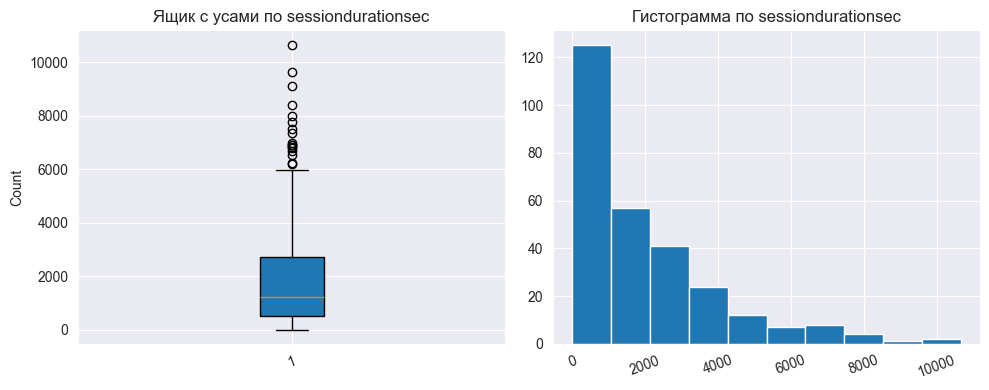

--------------------------------------------------------------------------------------------------------------------


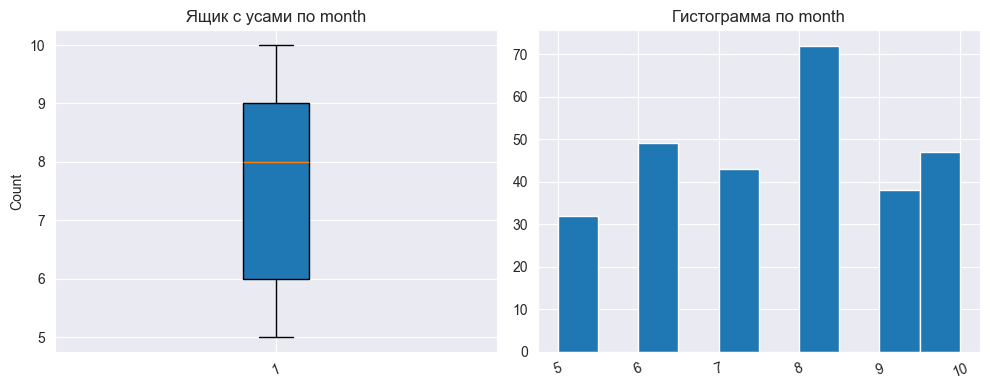

--------------------------------------------------------------------------------------------------------------------


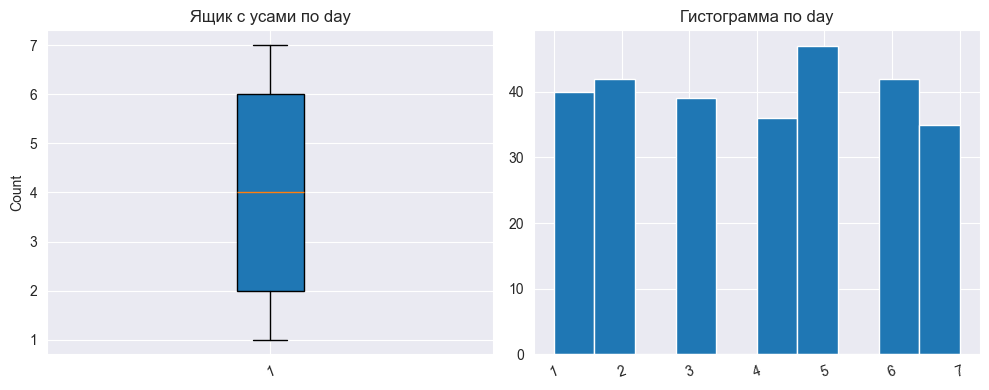

--------------------------------------------------------------------------------------------------------------------


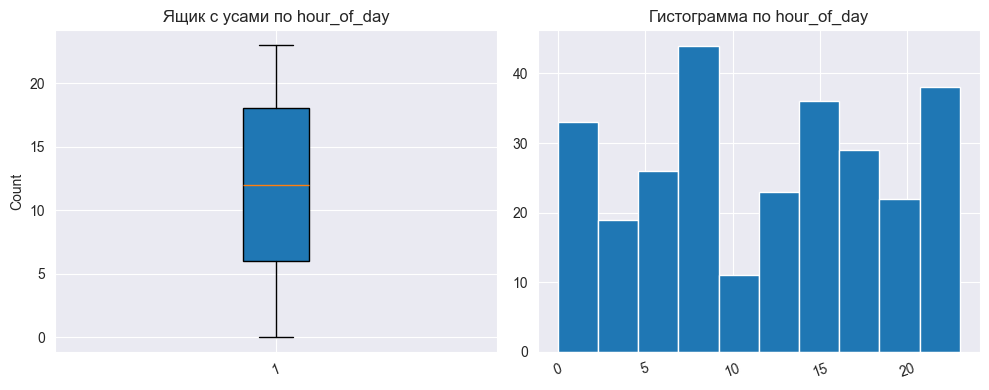

--------------------------------------------------------------------------------------------------------------------


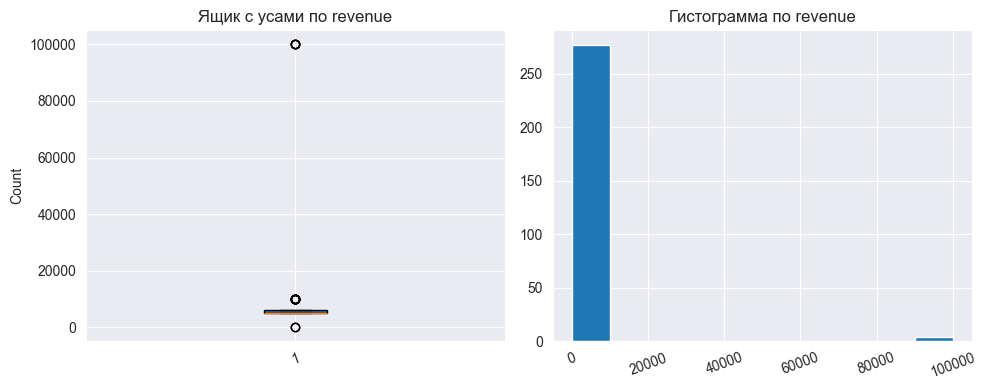

--------------------------------------------------------------------------------------------------------------------


In [273]:
# Для графического анализа, будем использовать bar/pie charts для категоральных данных и hist/boxplot для количественных данных


# Функция парного графика из bar и pie чартов
def draw_bar_pie(qual_count, col):
    categories = qual_count[col].index
    counts = qual_count[col].values

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

    # Bar plot слева
    ax1.bar(categories, counts)
    ax1.set_title(f'Столбчатая диаграмма по {col}')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20)
    # Pie chart справа
    ax2.pie(counts, labels=categories, autopct='%1.1f%%')
    ax2.set_title(f'Круговая диаграмма по {col}')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20)
    plt.show()


def draw_box_hist(df, col):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

    # box on the left
    ax1.boxplot(df[col], patch_artist=True)
    ax1.set_title(f'Ящик с усами по {col}')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20)

    # hist on the right
    ax2.hist(df[col])
    ax2.set_title(f'Гистограмма по {col}')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20)
    plt.show()


# Чтобы интерпретировать графики с датафрейма, эти функции берут графики по каждому нужному столбцу
def quantitative(df):
    for column in quant_col:
        draw_box_hist(df[df[column].notna()], column)
        print('-' * 116)


def qualitative(df):
    for column in qualit_col:
        draw_bar_pie(qual_count, column)
        print('-' * 116)


quantitative(payer_df)

Из графиков видно что помимо столбца revenue, также стоит уделить внимание столбцу sessiondurationsec, ведь скорее всего присутствуют выбросы в большую сторону над которыми стоит поработать, так как считаем что пользователь не может активно оформлять доставку долгое время. Скорее всего, он просто оставил сайт включенным, ничего не делая на нем (То есть был АФК), что будет искажать данные.

Проверим распределены ли данные в столбце продолжительности сессии нормально

In [274]:
statistic, pvalue = shapiro(df['sessiondurationsec'])
pvalue < 0.05

np.True_

Так как p_value < 0.05 у нас есть основания полагать что данные не распределены нормально. По этой причине, наша команда решила заполнить выбросы медианой по группе региона. Причиной выбора такого метода в том, что медиана устойчива к выбросам и асимметрии данных, что важно при нененормальном распределении.
Также мы учтем региональные особенности, ведь группировка по региону позволяет учесть локальные различия в поведении пользователей.



In [275]:
def median_for_region(row, column):  #функция для замены выбросов на медиану по группе региона
    return df[df['region'] == row['region']][column].median()


IQ = df['sessiondurationsec'].quantile(0.75) - df['sessiondurationsec'].quantile(0.25)
Upper_boundary = df['sessiondurationsec'].quantile(0.75) + 1.5 * IQ
print(
    f'В колонке sessiondurationsec обнаружены {len(df[df['sessiondurationsec'] > Upper_boundary])} грубых выбросов в большую сторону')
df['sessiondurationsec'] = df.apply(
    lambda x: median_for_region(x, 'sessiondurationsec') if (x['sessiondurationsec'] > Upper_boundary) else x[
        'sessiondurationsec'], axis=1)
#Для продолжительности сессии находим только выбросы в большую сторону
df['revenue'] = df.apply(
    lambda x: median_for_region(x, 'revenue') if ((x['revenue'] == 100000) | (x['revenue'] == 1)) else x['revenue'],
    axis=1)
df['revenue'].value_counts()

В колонке sessiondurationsec обнаружены 51 грубых выбросов в большую сторону


revenue
4999.0    197
5999.0     66
9999.0     18
Name: count, dtype: int64

In [276]:
payer_df = df[df['order_dt'].notna()]

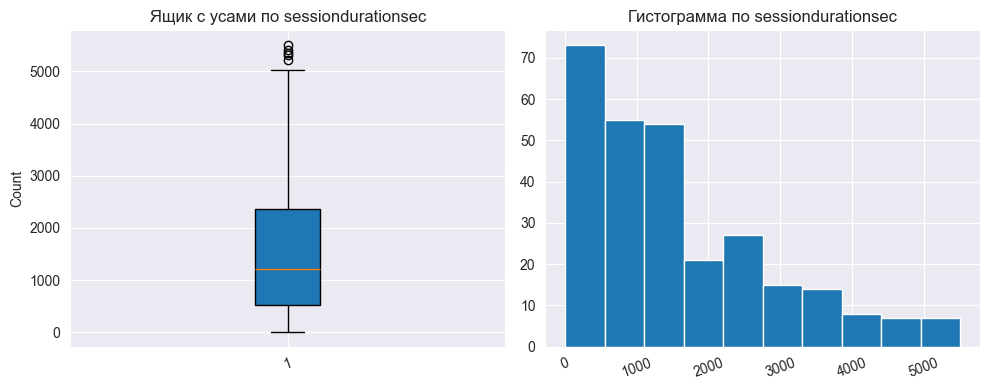

--------------------------------------------------------------------------------------------------------------------


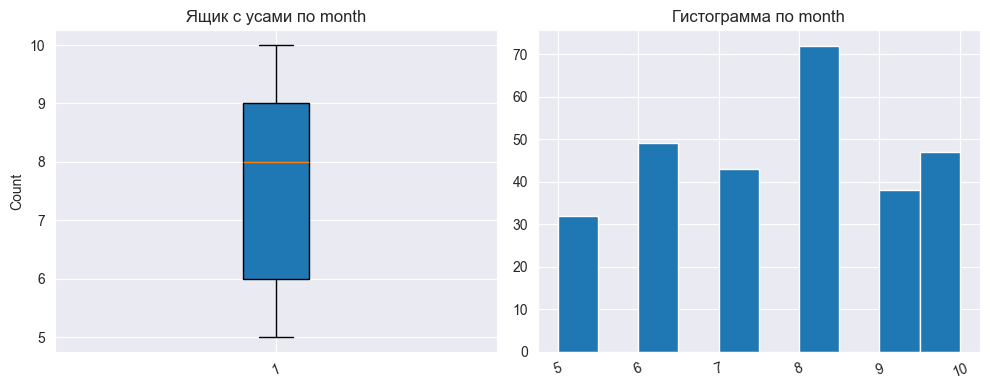

--------------------------------------------------------------------------------------------------------------------


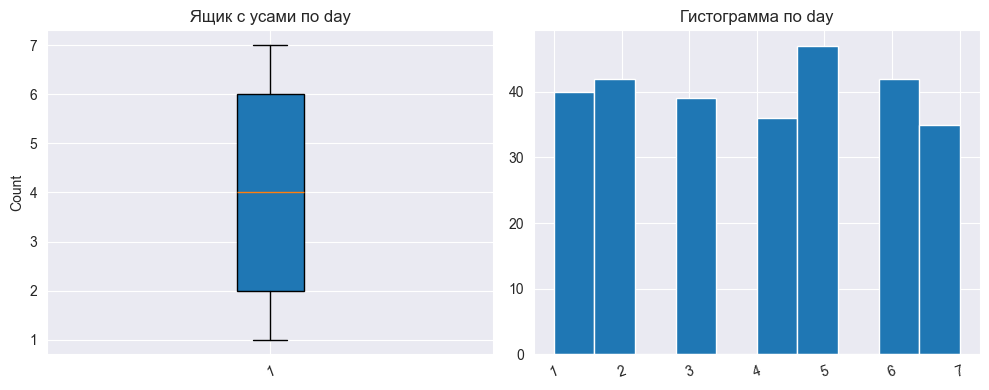

--------------------------------------------------------------------------------------------------------------------


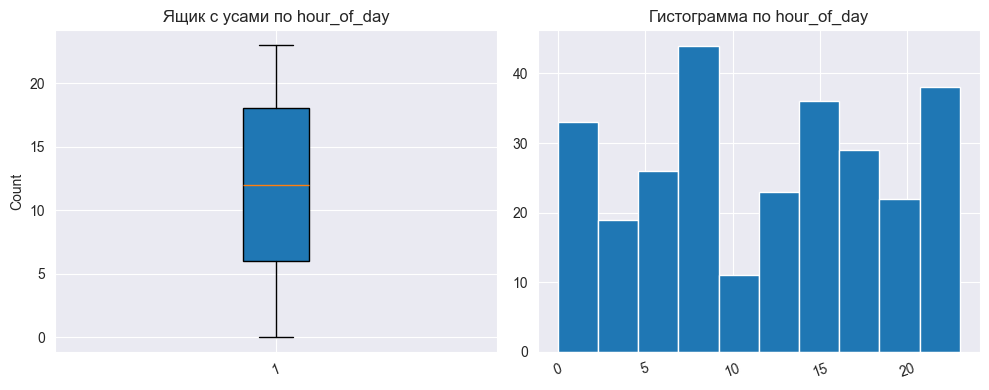

--------------------------------------------------------------------------------------------------------------------


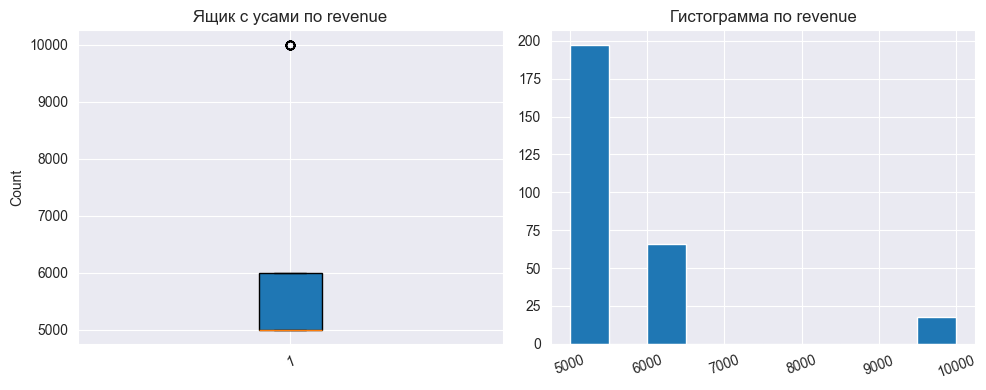

--------------------------------------------------------------------------------------------------------------------


In [277]:
quantitative(payer_df)

Визуальный анализ распределения количественных признаков показывает, что значительных выбросов в данных не наблюдается.
Что касается значения 10 000 в колонке 'revenue', оно действительно выделяется на фоне остальных транзакций. Однако наша команда считает данное наблюдение адекватным, поясняя, что:

Это значение не является аномалией, а скорее всего соответствует продаже определьного 'премиум' дрона, которые занимают верхний ценовой сегмент.

Разброс цен в данных отражает реальную структуру продаж, где наряду с бюджетными и средними устройствами присутствуют и высокотехнологичные решения.

Теперь займемся созданием необходимых столбцов

In [278]:
def final_rev(row):
    if row['promo_code'] == 1:
        return row['revenue'] * 0.9
    return row['revenue']


df['final_rev'] = df.apply(final_rev, axis=1)

payment_types = ['Mobile payments', 'Debit card', 'E-wallet', 'Cash', 'Credit card']
df['payer'] = df['payment_type'].apply(lambda x: 1 if x in payment_types else 0)


def categorize_time_period(row, hour='hour_of_day'):
    time_periods = {'утро': (6, 9),
                    'день': (10, 16),
                    'вечер': (17, 21),
                    'ночь': (21, 29)}
    start_session = row[hour]
    if start_session < 6:
        start_session = + 24
    for period, (period_start, period_end) in time_periods.items():
        if start_session <= period_end:
            return period


df['type_of_time'] = df.apply(categorize_time_period, axis=1)
payer_df = df[df['order_dt'].notna()]

При создании столбца о времени суток мы только учитываем время начала сессии, 
так как нам важно когда реклама "подействовала" на пользователя,
а когда сессия пользователя закончилась нам не важна в этом столбце.

Выводы по предобработке данных


# **Графический и аналитический анализ данных**

In [279]:
# Функция корреляций между колич и катег данными

def correlation_ratio(categories, values):
    grouped_means = values.groupby(categories).mean()
    overall_mean = values.mean()
    ss_between = ((grouped_means - overall_mean) ** 2 * categories.value_counts()).sum()
    ss_total = ((values - overall_mean) ** 2).sum()
    eta = np.sqrt(ss_between / ss_total)
    return eta


# Функция корелляций между качественными данными
def my_cramers(x, y):
    contab = pd.crosstab(x, y)
    chi2, p_value, dof, expected = chi2_contingency(contab)
    return np.sqrt(chi2 / (len(x) * (min(contab.shape) - 1)))

In [280]:
# dictionary нормального распределения для колич
norm = {}
for column in quant_col:
    statistic, p_value = shapiro(df[column])
    if p_value < 0.05:
        norm[column] = 'Спирмен'
    else:
        norm[column] = 'Пирсон'
norm

{'sessiondurationsec': 'Спирмен',
 'month': 'Спирмен',
 'day': 'Спирмен',
 'hour_of_day': 'Спирмен',
 'revenue': 'Пирсон'}

In [281]:
# Корреляционная матрица между всеми возможными столбцами в total_col

def correlation_matrix(df, norm=norm, total_col=total_col):
    correl = {}
    for col1 in total_col:
        exp = []
        for col2 in total_col:
            if col1 in quant_col and col2 in quant_col:
                if (norm[col1] == 'Пирсон') & (norm[col2] == 'Пирсон'):
                    exp.append(round(df[col1].corr(df[col2], method='pearson'), 4))
                else:
                    exp.append(round(df[col1].corr(df[col2], method='spearman'), 4))
            elif col1 in qualit_col and col2 in quant_col:
                exp.append(round(correlation_ratio(df[col1], df[col2]), 4))
            elif col2 in qualit_col and col1 in quant_col:
                exp.append(round(correlation_ratio(df[col2], df[col1]), 4))
            else:
                exp.append(round(my_cramers(df[col1], df[col2]), 4))
            correl[col1] = exp
    corr_df = pd.DataFrame(correl)
    corr_df.index = total_col
    return corr_df


corr_df = correlation_matrix(df[df['payer'] == 1])

Отсюда мы только видим слабую корреляцию между регионом и рекламным каналом

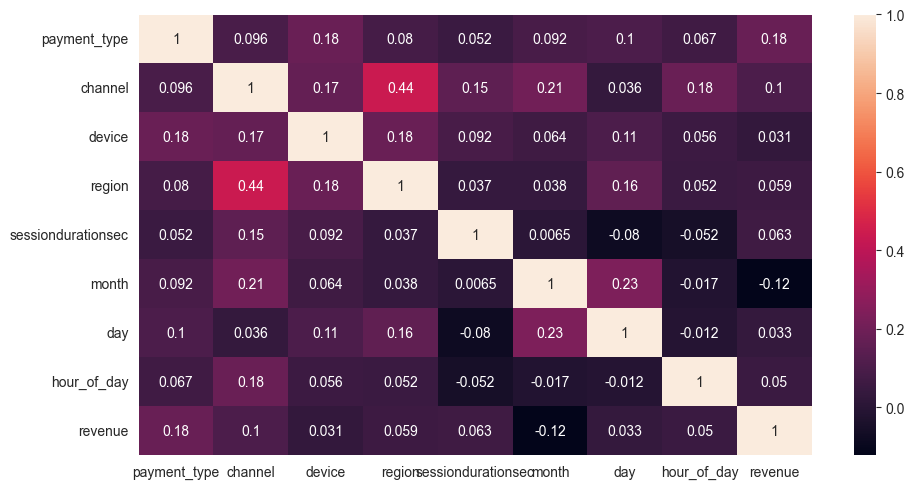

In [282]:
fig, ax1 = plt.subplots(1, figsize=(10, 5), tight_layout=True)
sns.heatmap(corr_df, annot=True)
plt.show()

In [283]:
qualit_col.append('type_of_time')
qual_count = {col: df[col].value_counts() for col in qualit_col}

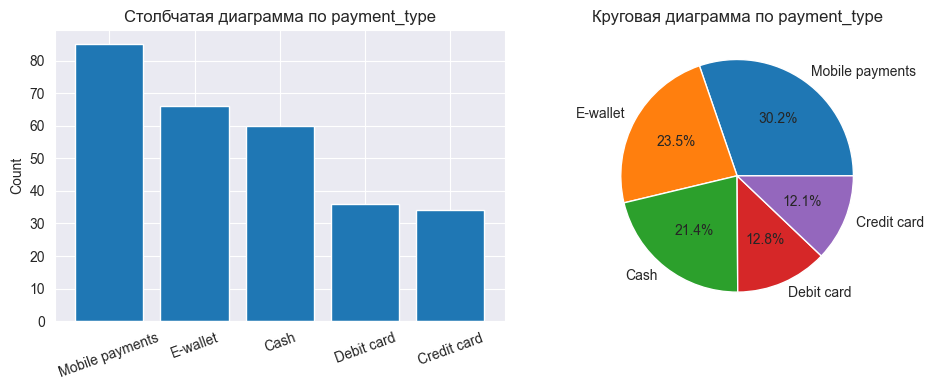

--------------------------------------------------------------------------------------------------------------------


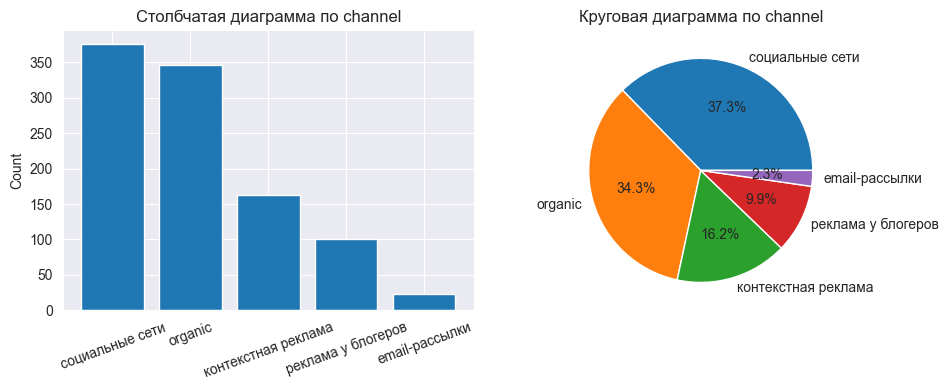

--------------------------------------------------------------------------------------------------------------------


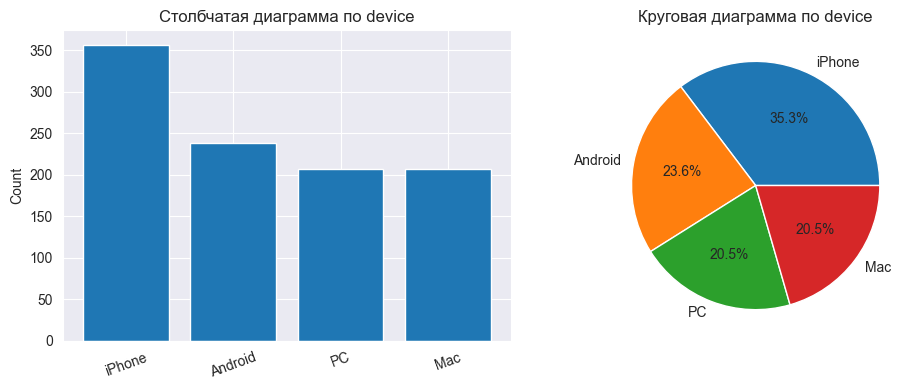

--------------------------------------------------------------------------------------------------------------------


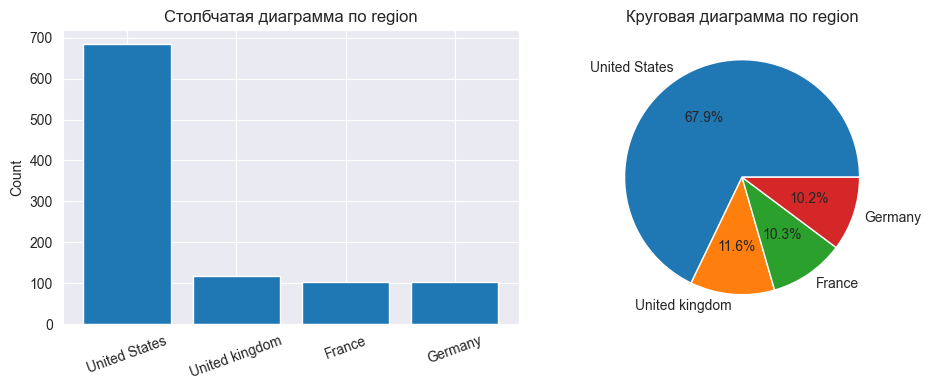

--------------------------------------------------------------------------------------------------------------------


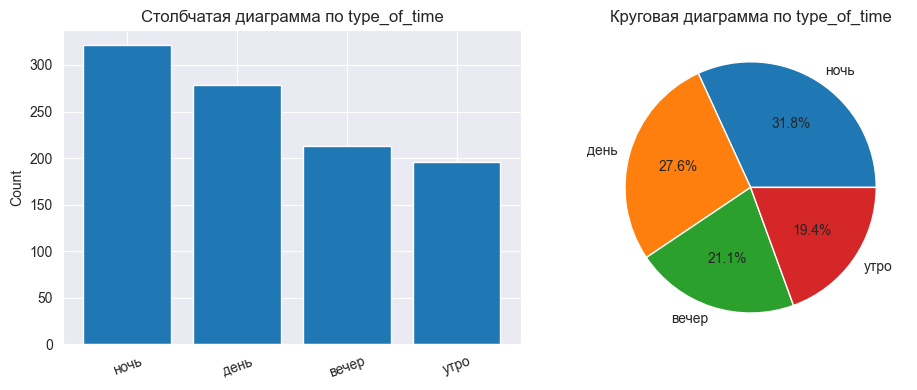

--------------------------------------------------------------------------------------------------------------------


In [284]:
qualitative(payer_df)

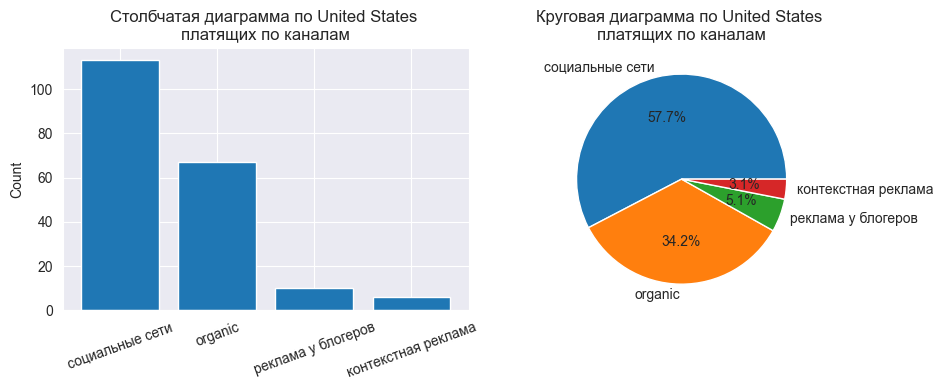

____________________________________________________________________________________________________________________


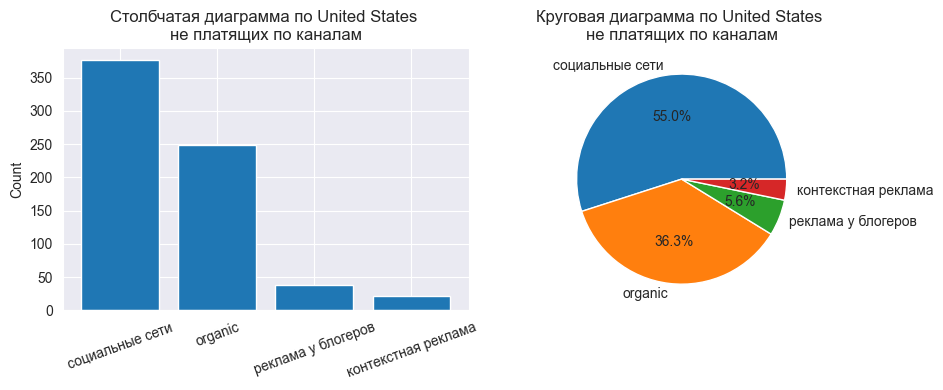

____________________________________________________________________________________________________________________


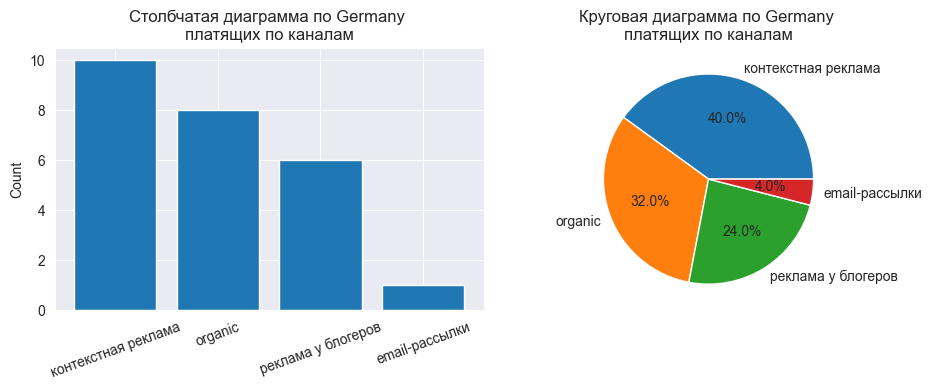

____________________________________________________________________________________________________________________


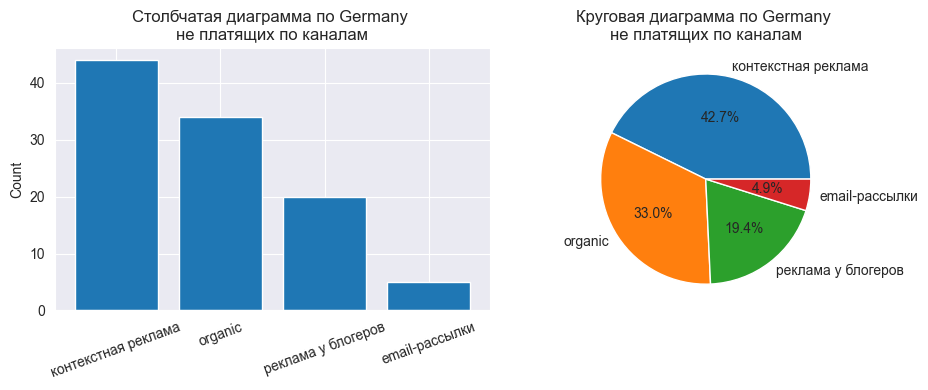

____________________________________________________________________________________________________________________


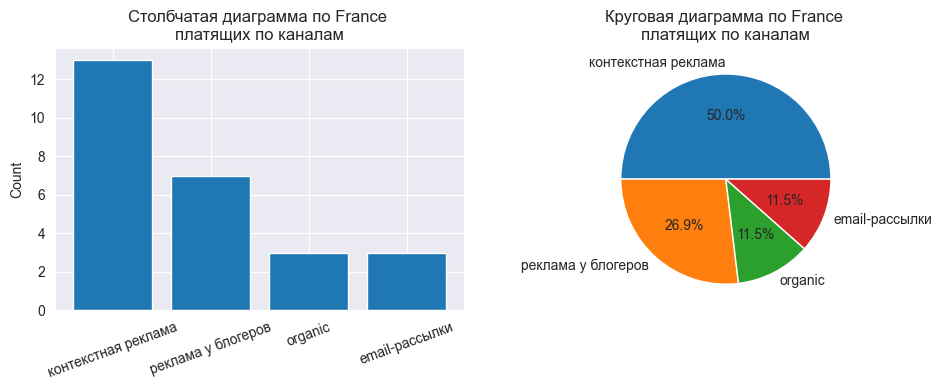

____________________________________________________________________________________________________________________


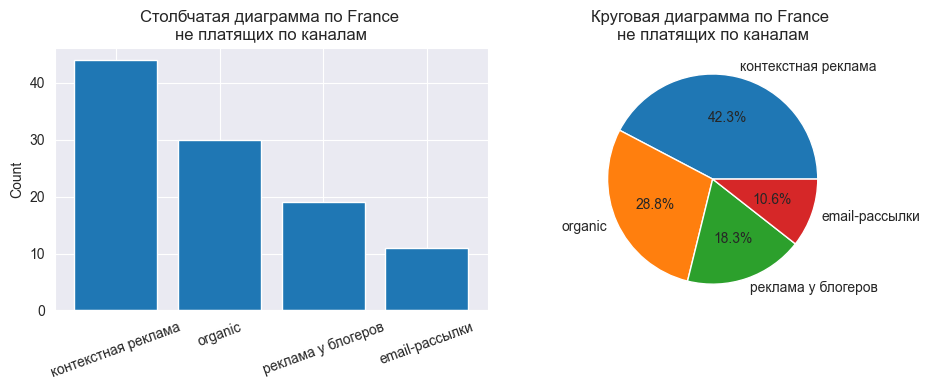

____________________________________________________________________________________________________________________


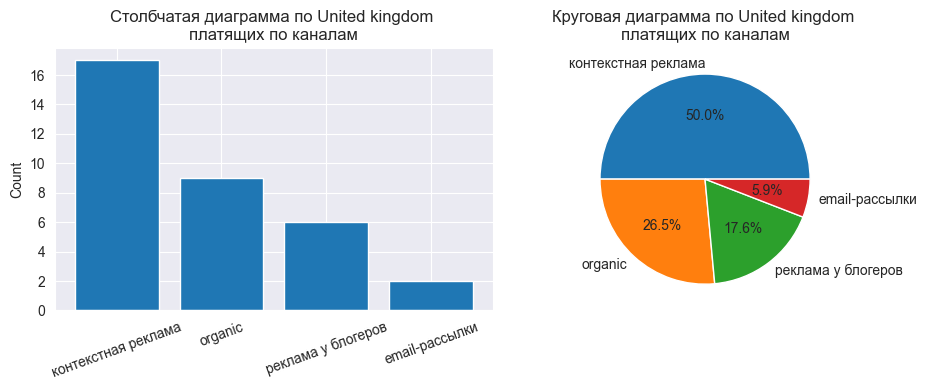

____________________________________________________________________________________________________________________


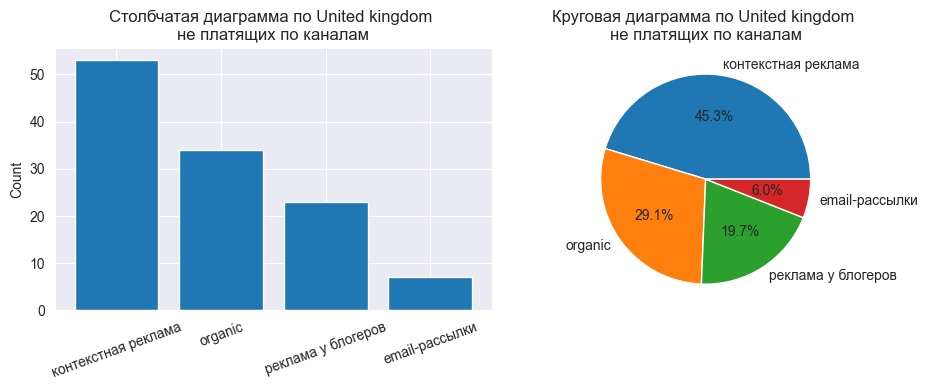

____________________________________________________________________________________________________________________


In [285]:
for region in payer_df.region.unique():
    draw_bar_pie(payer_df[payer_df['region'] == region]['channel'].value_counts().to_frame().rename(
        columns={'count': f"{region} \nплатящих по каналам"}), f"{region} \nплатящих по каналам")
    print('_' * 116)
    draw_bar_pie(df[df['region'] == region]['channel'].value_counts().to_frame().rename(
        columns={'count': f"{region} \nне платящих по каналам"}), f"{region} \nне платящих по каналам")
    print('_' * 116)


По region


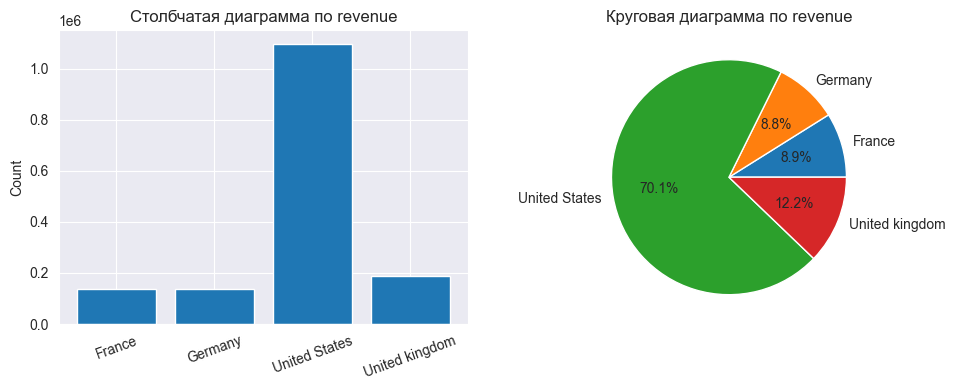

--------------------------------------------------------------------------------------------------------------------


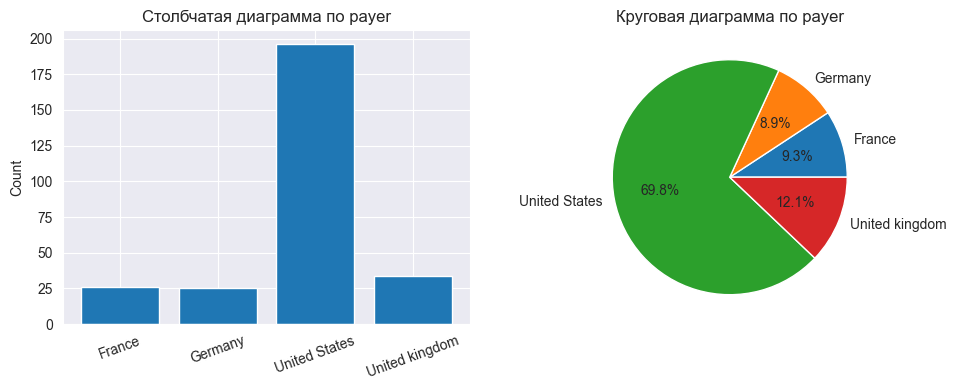

--------------------------------------------------------------------------------------------------------------------
По channel


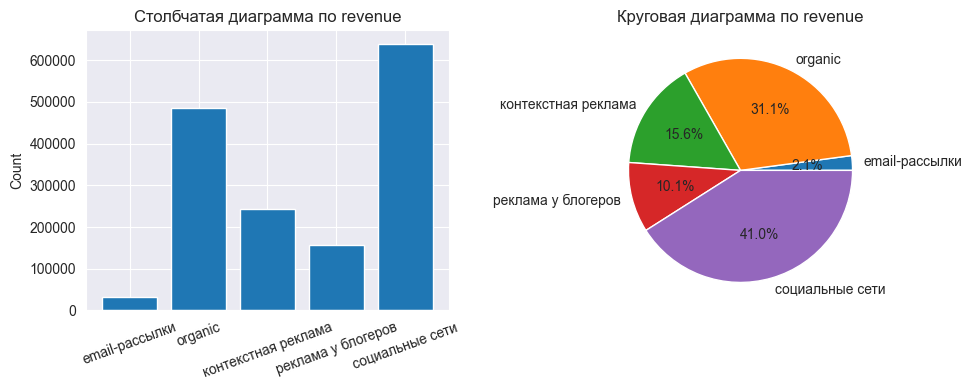

--------------------------------------------------------------------------------------------------------------------


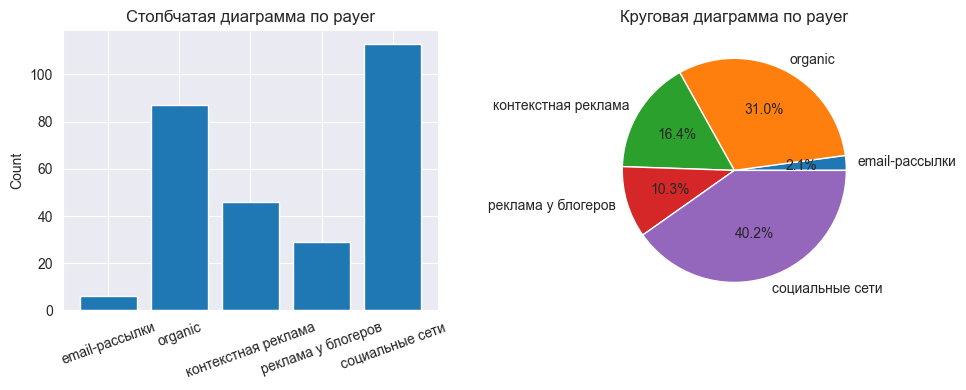

--------------------------------------------------------------------------------------------------------------------
По device


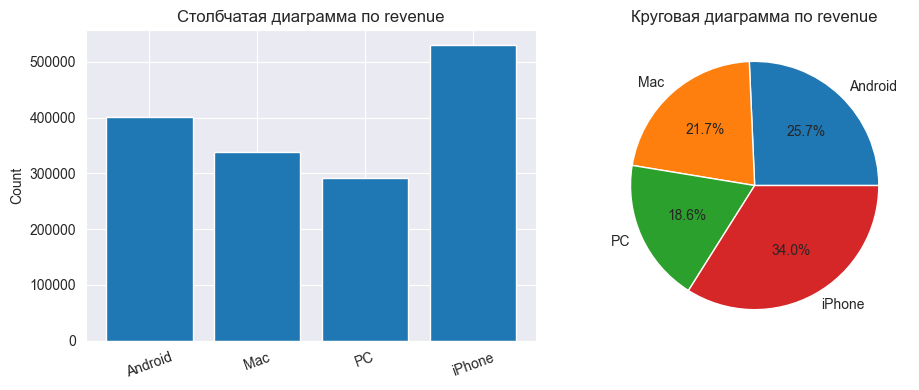

--------------------------------------------------------------------------------------------------------------------


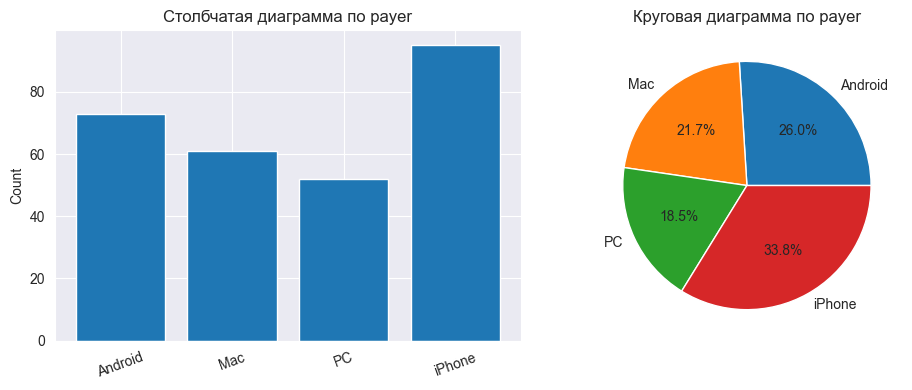

--------------------------------------------------------------------------------------------------------------------


In [286]:
# Анализируем доли продаж по региону, каналу, устройству общее количество проданных денег, количество продаж и соотношение денег на одного покупателя
for col in ['region', 'channel', 'device']:
    quantity = payer_df.groupby(col)['payer'].count().to_frame()
    revenue = df.groupby(col)['revenue'].sum().to_frame()
    print(f'По {col}')
    draw_bar_pie(revenue, 'revenue')
    print('-' * 116)
    draw_bar_pie(quantity, 'payer')
    print('-' * 116)

In [287]:
# Для количества пользователей с разбивкой на платящих/не платящих, используем функцию, которая принмаает два датафрейма, первый платящих, второй не платящих

def plot_payer_bars(df1, df2):
    combined = pd.merge(
        df1.rename(columns={'payer': 'Payers'}),
        df2.rename(columns={'payer': 'Non-Payers'}),
        left_index=True,
        right_index=True,
        how='outer'
    )

    for i in combined.index:
        payers = combined.loc[i, 'Payers']
        non_payers = combined.loc[i, 'Non-Payers']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3))

        # Столбчатая диаграмма на ax1
        ax1.bar(['Payers', 'Non-Payers'], [payers, non_payers], color=['royalblue', 'navy'])
        ax1.set_title(f'Платящих в {i}')
        ax1.set_ylabel('Count')

        # Круговая на ax2
        ax2.pie([payers, non_payers], labels=['Payers', 'Non-Payers'],
                autopct='%1.1f%%', colors=['royalblue', 'navy'])
        ax2.set_title(f'Пропорция в {i}')

        plt.tight_layout()
        plt.show()
        print('-' * 116)

По region


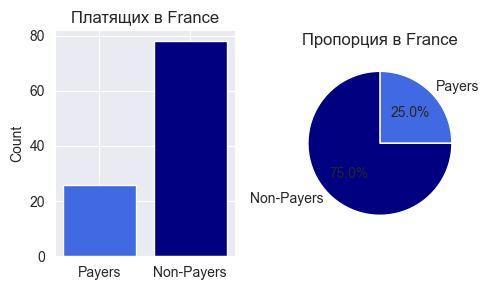

--------------------------------------------------------------------------------------------------------------------


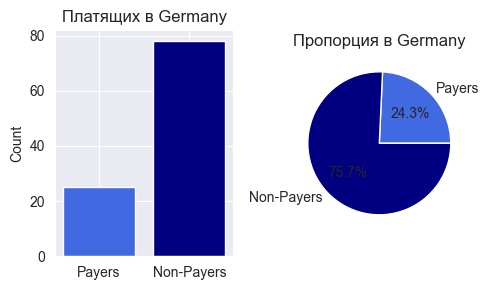

--------------------------------------------------------------------------------------------------------------------


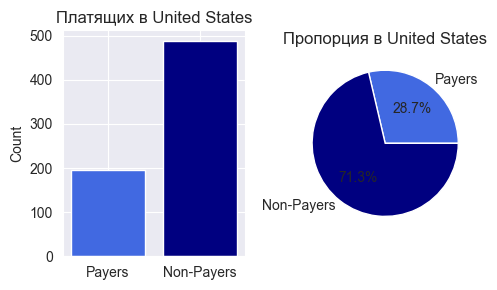

--------------------------------------------------------------------------------------------------------------------


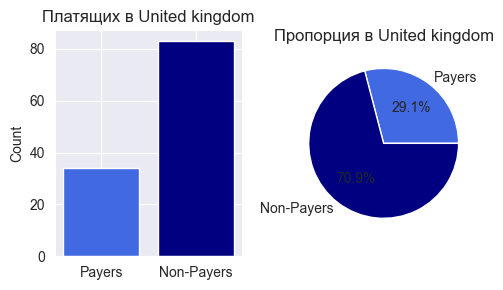

--------------------------------------------------------------------------------------------------------------------
По channel


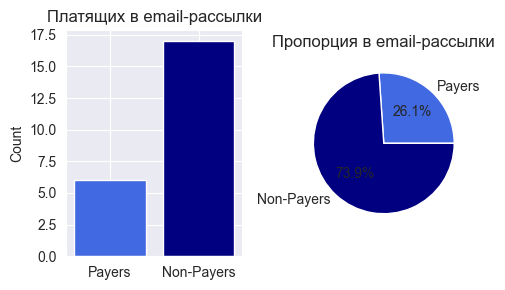

--------------------------------------------------------------------------------------------------------------------


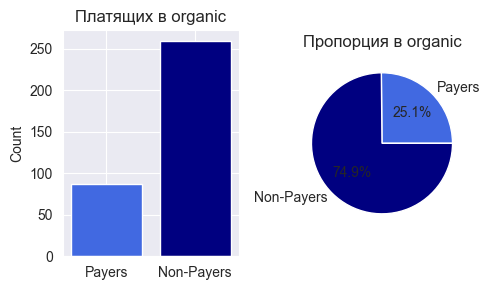

--------------------------------------------------------------------------------------------------------------------


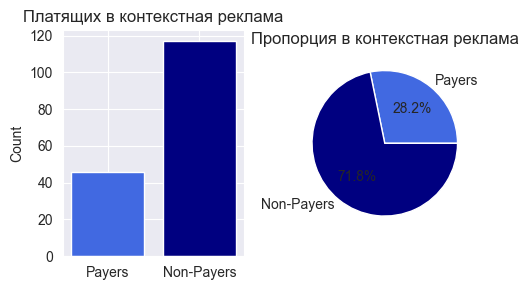

--------------------------------------------------------------------------------------------------------------------


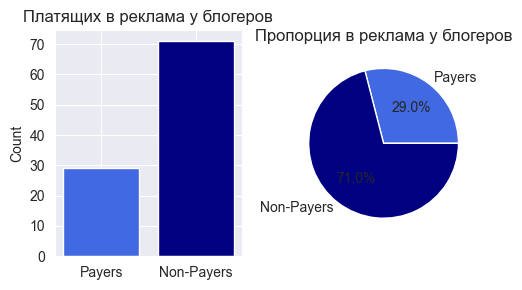

--------------------------------------------------------------------------------------------------------------------


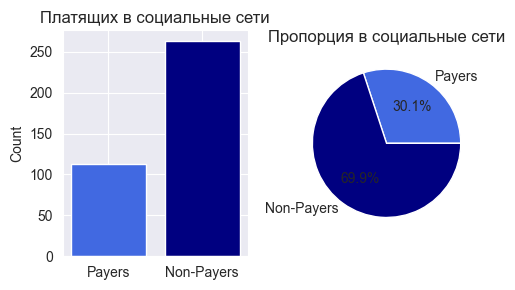

--------------------------------------------------------------------------------------------------------------------
По device


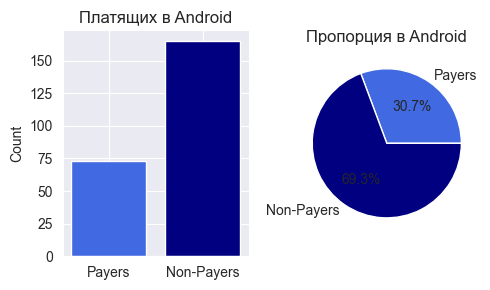

--------------------------------------------------------------------------------------------------------------------


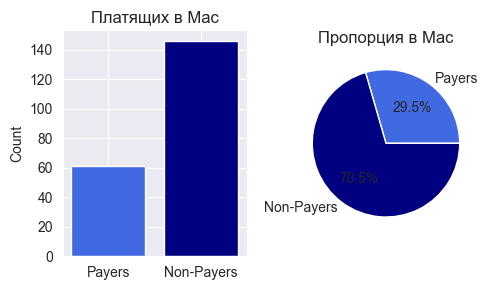

--------------------------------------------------------------------------------------------------------------------


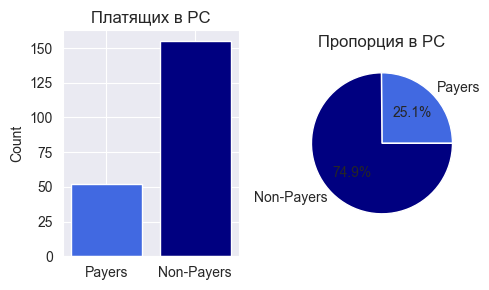

--------------------------------------------------------------------------------------------------------------------


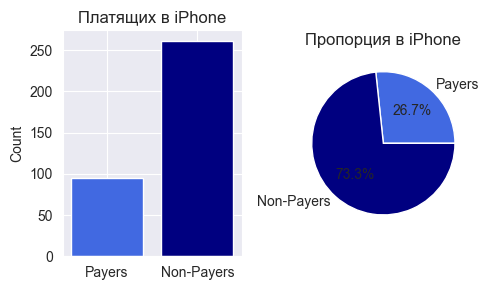

--------------------------------------------------------------------------------------------------------------------


In [288]:
## доли платящих/не платящих
for col in ['region', 'channel', 'device']:
    payers = df[df['payer'] == 1].groupby(col)['payer'].count().to_frame()
    nonpayers = df[df['payer'] == 0].groupby(col)['payer'].count().to_frame()
    print(f'По {col}')
    plot_payer_bars(payers, nonpayers)

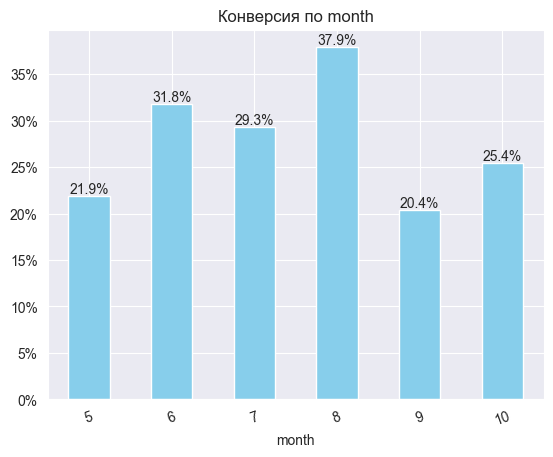

--------------------------------------------------------------------------------------------------------------------


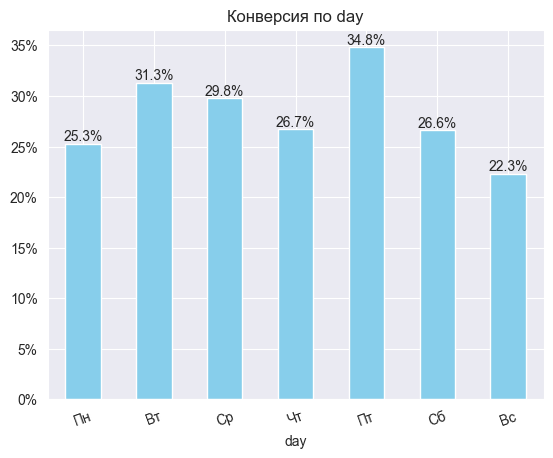

--------------------------------------------------------------------------------------------------------------------


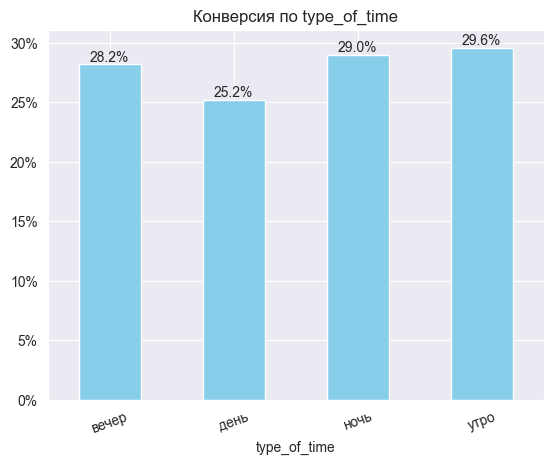

--------------------------------------------------------------------------------------------------------------------


In [289]:
# количество платящих по месяцам/дня/времени для сезонности
for col in ['month', 'day', 'type_of_time']:
    ax = round(
        df[df['payer'] == 1].groupby(col)['payer'].count() / (
                df[df['payer'] == 1].groupby(col)['payer'].count() + df[df['payer'] == 0].groupby(col)[
            'payer'].count()) * 100,
        1).plot.bar(color='skyblue')
    ax.set_yticklabels([f'{y.get_text()}%' for y in ax.get_yticklabels()])
    if col == 'month':
        ax.set_xticklabels(payer_df['month'].unique())
    if col == 'day':
        ax.set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
    for cont in ax.containers:
        ax.bar_label(
            cont,
            labels=[f'{val}%' for val in cont.datavalues],
        )
    plt.title(f'Конверсия по {col}')
    plt.xticks(rotation=20)
    plt.show()
    print('-' * 116)

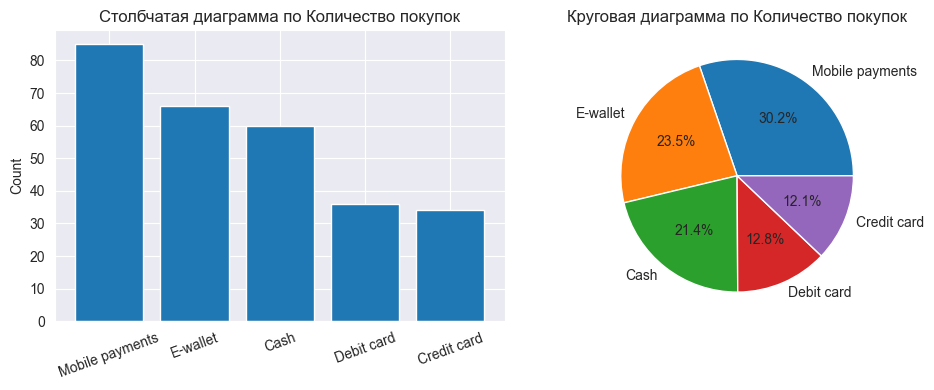

In [290]:
# Количество покупок через разные способы оплаты
pay_quant = df[df['payment_type'].notna()]['payment_type'].value_counts().to_frame()
pay_quant.columns = pay_quant.columns.str.replace('count', 'Количество покупок')
draw_bar_pie(pay_quant, 'Количество покупок')

### Выводы

#### **Трафик и активность пользователей:**
- Наибольшее число заходов зафиксировано в **августе**, наименьшее — в **мае**.
- Пик активности приходится на **пятницу и субботу**, минимальное число посещений — в **четверг и воскресенье**.
- По времени суток:
  - Максимальная активность — **ночью (ближе к утру) и днем**.
  - Минимальная — **утром (к 10–11 часам)**.
#### **Способы оплаты:**
- Наиболее популярный метод — **mobile payments**.
- Реже всего используются **дебетовые/кредитные карты**.

#### **Источники трафика:**
- Основные каналы — **соцсети** и **organic-трафик**.
- На **email** приходится всего **2%** заходов.

#### **Устройства:**
- Более **трети** пользователей заходят с **iPhone**.
- **Компьютеры (PC/Mac)** используются реже, чем мобильные устройства.
- Более **2/3 трафика** поступает из **США**.

---

#### **Доходы и конверсия:**

1. **Средний доход на платящего пользователя (revenue/payer)**
   - По всем факторам (страны, каналы, устройства) значения близки, поэтому важно оптимизировать **каждый фактор отдельно**.

2. **География:**
   - **70%** платежей поступает из **США** — ключевой рынок.
   - Наибольшая **доля платящих пользователей** — в **Великобритании (29,1%)**.

3. **Каналы привлечения:**
   - **41%** доходов генерируется через **соцсети**.
   - **Конверсия в платежи** также выше всего у **соцсетей (30,1%)**.

4. **Устройства:**
   - **iPhone** лидирует по трафику, но **конверсия в платежи** у него ниже (**26,7%**).
   - Наибольшая склонность к покупкам у **Android-пользователей (30,7%)** и **Mac-пользователей (29,5%)**.

**Рекомендация:**
Улучшение конверсии среди **пользователей iPhone** (за счет оптимизации UX, платежных методов и таргетированных предложений) может значительно увеличить доход из-за их высокой доли в трафике.

# **Проведение расчетов**

**Расчет среднего чека**

In [291]:
print(f'Средний чек среди платящих пользователей: {payer_df['revenue'].mean()}')
print(f'Средний чек среди всех пользователей: {df['revenue'].sum() / df.shape[0]}')

Средний чек среди платящих пользователей: 5554.160142348755
Средний чек среди всех пользователей: 1548.3323412698412


In [292]:
unique_users_df = df.drop_duplicates(subset=['user_id'])  # Создаем датафрейм только с уникальными айди пользователей

**Сколько покупок в среднем делает 1 пользователь**

In [293]:
number_of_purchases = []  # Список хранящий количество покупок от каждого уникального пользователя
for i in df['user_id'].unique():
    user_revenue = df[df['user_id'] == i]['revenue']
    purchases = user_revenue[user_revenue > 0].count()
    number_of_purchases.append(purchases)
print(f'Всего платящих пользователй {payer_df.shape[0]}')
print(np.round(np.mean(number_of_purchases), 2))

Всего платящих пользователй 281
0.28


Это значит что каждый 4 пользователь совершает покупку на сайте

**Средняя продолжительность сессии по рекламным каналам**

In [294]:
df.pivot_table(index=['channel'], values=['sessiondurationsec'], aggfunc=lambda x: x.mean() / 60).rename(
    columns={'sessiondurationsec': 'продолж_сессии_в_минутах'}).sort_values('продолж_сессии_в_минутах',
                                                                            ascending=False).round(1)

,продолж_сессии_в_минутах
channel,
контекстная реклама,27.7
реклама у блогеров,25.6
социальные сети,24.7
organic,24.4
email-рассылки,23.5


Как мы видим пользователи зашедшие через контекстную рекламу проводят больше всего времени на сайте

**Средняя продолжительность сессии по устройствам**

In [295]:
df.pivot_table(index=['device'], values=['sessiondurationsec'], aggfunc=lambda x: x.mean() / 60).rename(
    columns={'sessiondurationsec': 'продолж_сессии_в_минутах'}).sort_values('продолж_сессии_в_минутах', ascending=False)


,продолж_сессии_в_минутах
device,
Android,25.289951
iPhone,25.286517
PC,25.007770
Mac,24.782085


Создадим функцию  determine_average_revenue(df, column), которая выполняет анализ среднего дохода по категориям и возвращает топ-3 категорий с наибольшей выручкой.

In [296]:
def determine_average_revenue(df, column):
    return (df.pivot_table(index=[column], values=['revenue'], aggfunc='mean').nlargest(3, 'revenue'))

**Топ-3 месяца по среднему чеку с разбивкой по регионам**

In [297]:
for i in df.region.unique():
    print(i)
    print(determine_average_revenue(df[df['region'] == i], 'month'))
    print('-' * 50)

United States
           revenue
month             
5      6259.869565
8      5728.166667
6      5665.666667
--------------------------------------------------
France
           revenue
month             
6      5570.428571
5      5499.000000
10     5332.333333
--------------------------------------------------
Germany
       revenue
month         
7       7499.0
6       5799.0
9       5249.0
--------------------------------------------------
United kingdom
           revenue
month             
10     6141.857143
8      5635.363636
5      5499.000000
--------------------------------------------------


Отсюда можно заметить что Июль вышел очень прибыльным у Германии, и почти в каждом регионе, прибыльными оказываются Май и Июнь

**Топ 3 региона по среднему чеку:**

In [298]:
determine_average_revenue(df, 'region')

,revenue
region,
United kingdom,5587.235294
United States,5585.734694
Germany,5479.000000


**Топ 3 рекламных канала по среднему чеку**

In [299]:
determine_average_revenue(df, 'channel')

,revenue
channel,
социальные сети,5662.716814
organic,5585.206897
email-рассылки,5499.000000


**MAU по каждому месяцу с разбивкой по рекламным каналам и выделение топ-3 рекламных каналов по количеству уникальных пользователей в месяц.**

In [300]:
monthly_unique_users = []
for i in df.month.unique():
    monthly_data = df[df['month'] == i]
    # Используем метод unique для подсчета количества только уникальных пользователей
    unique_users = monthly_data.groupby('channel')['user_id'].nunique().reset_index()
    unique_users['month'] = i
    monthly_unique_users.append(unique_users)
summary_df = pd.concat(monthly_unique_users)
tablee = summary_df.groupby(['channel', 'month'])['user_id'].sum().reset_index()
tablee.columns = ['channel', 'month', 'unique_users_this_month']
tablee


,channel,month,unique_users_this_month
0,email-рассылки,5,7
1,email-рассылки,6,1
2,email-рассылки,7,3
3,email-рассылки,8,4
4,email-рассылки,9,2
5,email-рассылки,10,6
6,organic,5,76
7,organic,6,59
8,organic,7,46
9,organic,8,60


In [301]:
overall_performance = summary_df.groupby('channel')['user_id'].sum().reset_index()
overall_performance.columns = ['channel', 'total_monthly_unique_users']
top_3_channels = overall_performance.sort_values('total_monthly_unique_users', ascending=False).head(3)
print("Top 3 Channels")
top_3_channels

Top 3 Channels


,channel,total_monthly_unique_users
4,социальные сети,373
1,organic,346
2,контекстная реклама,163


Как мы видим наибольшее количество уникальных пользователей приходят через социальные сети.
Стоит учесть что в этой таблице мы посчитали именно количество уникальных пользователей в месяц.
То есть, если пользователь А зашел на сайт в июле, а затем он зашел в августе, то он и в июле и в августе будет считаться уникальным

In [302]:
unique_users_df = df.drop_duplicates('user_id')
unique_users_df.groupby('channel').agg(unique_users=('user_id', 'count'), Number_of_payer_users=('payer', 'sum'),
                                       total_revenue=('revenue', 'sum')).sort_values('total_revenue',
                                                                                     ascending=False).reset_index()

,channel,unique_users,Number_of_payer_users,total_revenue
0,социальные сети,369,111,629889.0
1,organic,346,87,485913.0
2,контекстная реклама,159,42,223958.0
3,реклама у блогеров,100,29,157971.0
4,email-рассылки,23,6,32994.0


Тут мы уже учитывали уникальных пользователей в общей плане. Повторный заход пользователей в любое время уже не будут учитываться как заход уникального пользователя

### **Выводы по расчетам:**
1. Средний чек среди платящих пользователей оказался равен 5554, а средний чек среди всех пользователей оказался равен 1548.  

2. 281 пользователей совершили покупки на сайте. Примерно каждый четвертый пользователь совершает покупку на сайте

3. Пользователи пришедшие на сайт через контекстную рекламу проводят больше всего времени на сайте

4. Пользователи использующие мобильные устройства проводят больше всего времени на сайте

5. Топ 3 рекламных канала по наибольшему среднему чеку: 3. Реклама у блогеров, 2. Organic 1. Социальные сети. Как мы видим хоть и пользователи 
    пришедшие через контекстную рекламу больше всего времени проводят на сайте, их средний чек не входит в топ 3

6. Топ 3 региона по среднему чеку являются: 1. Великобритания 2.США 3. Германия

7. В июле В Германии зафиксирован единственный случай, когда средний чек превысил отметку в 7000.

8. Среди всех регионов, почти всегда в топ 3 входят Июнь и Май

9. Рекламный канал социальные сети привлекает больше всего платящих пользователей

10. Рекламный канал email-рассылки занимает последнее место по привлечению пользователей и по приносу дохода

# **Проверка гипотез:**

Так как при проверке гипотез мы будем использовать методы которые будут часто повторяться при написании кода, стоит написать класс для более эффективной проверки гипотез

Для этого мы решили создать материнский класс Analyzer. Из него будет идти 3 дочерних класса - анализы между количественными/количественными, анализы между количественными/номинальными, анализы между номинальными/номинальными

In [303]:
(
    payer_df.groupby('device')['payment_type']
    .value_counts(normalize=True)
    .mul(100)
    .groupby(level=0)
    .nlargest(1)
    .droplevel(1)
    .sort_values(ascending=False)
    .round(2)
    .reset_index(name='процент')
    .rename(columns={
        'device': 'Девайс',
        'payment_type': 'Метод платежа'
    })
    .style
    .set_properties(**{
        'background-color': '#f8f9fa',  # Light gray background
        'color': '#212529',  # Dark text
        'border': '1px solid #dee2e6',  # Subtle border
        'font-family': 'Arial, sans-serif'
    })
    .set_properties(subset=['Девайс', 'Метод платежа'], **{
        'text-align': 'center'  # Center-align text columns
    })
    .set_properties(subset=['процент'], **{
        'text-align': 'right'  # Right-align percentages
    })
    .format({'процент': '{:.2f}%'})  # Percentage format
    .set_table_styles([
        {  # Header style
            'selector': 'th',
            'props': [
                ('background-color', '#495057'),  # Dark header
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-transform', 'uppercase'),
                ('text-align', 'center')
            ]
        },
        {  # Cell padding
            'selector': 'td',
            'props': [('padding', '8px 12px')]
        }
    ])
    .set_caption(
        '<h4 style="text-align:center;margin-bottom:12px;color:#495057">'
        'Топ-1 платежные методы по устройствам</h4>'
    )
)

,Девайс,Метод платежа,процент
0,iPhone,Mobile payments,40.00%
1,PC,Cash,36.54%
2,Mac,E-wallet,34.43%
3,Android,Cash,28.77%


При этом мы должны учитывать некотрые условия для использования метода ANOVA и Kruskal-Wallis.
ANOVA: Ни в одной группе не должно быть всего 1 наблюдение (иначе оценка дисперсии невозможна).
Kruskal-Wallis: Хотя бы в одной группе ≥4 наблюдения (иначе тест может потерять мощность). 
Ни в одной группе не должно быть всего 1 уникального наблюдение (иначе ранжирование невозможно)

In [304]:
class Analyzer:
    def __init__(self, data):
        self.data = data
        self.pval = None
        self.statistics = None
        self.method = None

    def normal_spread_check(self, column):
        alpha = 0.05
        stat, p_value = shapiro(self.data[column])
        if p_value > alpha:
            return True
        else:
            return False

    def result(self):
        alpha = 0.05
        if self.pval < alpha:
            return f'Отклоняем нулевую гипотезу ведь найдено влияние {self.column1} на {self.column2} ведь (p-value={self.pval:.4f})'
        else:
            return f'Нет значимого влияния между {self.column1} и {self.column2} (p={self.pval:.4f}'


class numerical_numerical(Analyzer):
    def __init__(self, data, column1, column2):
        super().__init__(data)
        self.column1 = column1
        self.column2 = column2
        self.pval = None

        if self.normal_spread_check(column1) and self.normal_spread_check(column2):
            self.correlation_analysis(method='pearson')
        else:
            self.correlation_analysis(method='spearman')

    def correlation_analysis(self, method):
        if method == 'pearson':
            self.pval = pearsonr(self.data[self.column1], self.data[self.column2])[1]
        else:
            self.pval = spearmanr(self.data[self.column1], self.data[self.column2])[1]


class Categorical_categorical(Analyzer):
    def __init__(self, data, column1, column2):
        super().__init__(data)
        self.column1 = column1
        self.column2 = column2
        self.table = None
        self.chi_2()

    def chi_2(self):
        self.method = 'Chi-2'
        df_two_categorical_factors = self.data[[self.column1, self.column2]]
        self.crosstable = pd.crosstab(df_two_categorical_factors[self.column1],
                                      df_two_categorical_factors[self.column2])
        self.pval = chi2_contingency(self.crosstable)[1]

    def result(self):
        alpha = 0.05
        if self.pval < alpha:
            return super().result()
        else:
            return f'Не найдено связи между {self.column1} и {self.column2} так как (p={self.pval:.4f}'


class numerical_categorical(Analyzer):
    def __init__(self, data, groups, col_name, target_name):
        super().__init__(data)
        self.groups = groups
        self.target = target_name
        self.col_name = col_name
        self.num_groups = len(groups)

        if self.num_groups == 2:
            if self.check_normality_groups():
                self.statistics, self.pval = ttest_ind(*self.groups)
                self.method = 'Student t-test'
            else:
                self.statistics, self.pval = mannwhitneyu(*self.groups)
                self.method = 'Mann-Whitney U'
        else:
            if self.check_normality_groups():
                if any(len(group) < 2 for group in self.groups) or any(
                        len(np.unique(group)) == 1 for group in self.groups):
                    # Проверка критериев использования ANOVA
                    self.pval = 'undefined'
                else:
                    self.statistics, self.pval = f_oneway(*self.groups)
                    self.method = 'ANOVA'
            else:  # Проверка критериев использования Краскелла-Уолиса
                criteria1 = False
                criteria2 = True
                for i in self.groups:
                    if len(i) >= 4:
                        criteria1 = True
                    if len(i) < 2:
                        criteria2 = False
                if criteria1 and criteria2:
                    self.statistics, self.pval = kruskal(*self.groups)
                    self.method = 'Kruskal-Wallis'
                else:
                    self.pval = 'undefined'

    def check_normality_groups(self):  # Проверка нормальности в группах
        alpha = 0.05
        for group in self.groups:
            if shapiro(group)[1] < alpha:
                return False
        return True

    def result(self):  # Вывод результата проверки
        alpha = 0.05
        if self.pval == 'undefined':
            return (f'Недостаточно данных в группах чтобы проверить влияние {self.col_name} на {self.target}')
        elif self.pval < alpha:
            return (f'Обнаружен значимый эффект для {self.col_name} на {self.target}'
                    f'(p={self.pval:.6f}, метод={self.method}, статистика={self.statistics:.2f})')
        else:
            return (f'Значимый эффект для {self.col_name} на {self.target} не обнаружен '
                    f'(p={self.pval:.6f}, метод={self.method})')

Наша команда решила разкодировать номера месяца и номера дней недели на их название. Также мы решили убрать кодировку для столбца наличия промокода. Также мы изменили столбец на конкретное число месяца

In [305]:
month_map = {
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October'
}
day_of_the_week_map = {
    1: 'Понедельник',
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота',
    7: 'Воскресенье'
}

payer_df.loc[:, 'dayofweek'] = (payer_df['order_dt'].dt.dayofweek + 1).map(day_of_the_week_map)
payer_df.loc[:, 'month'] = payer_df['month'].map(month_map)
payer_df.loc[:, 'promo_code'] = payer_df['promo_code'].apply(lambda x: 'Yes' if x == 1 else 'No')
payer_df.loc[:, 'day'] = payer_df['order_dt'].dt.day
payer_df.head(5)

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,final_rev,payer,type_of_time,dayofweek
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.0,2019-05-01,May,1,0,2019-05-01 00:06:40,9999.0,Mobile payments,No,9999.0,1,ночь,Среда
20,771147371911,United States,Android,organic,2019-05-06 15:49:16,2019-05-06 15:53:16,240.0,2019-05-06,May,6,15,2019-05-06 15:49:16,4999.0,Mobile payments,No,4999.0,1,день,Понедельник
28,245941309860,Germany,Mac,organic,2019-05-07 12:00:49,2019-05-07 13:10:26,4177.0,2019-05-07,May,7,13,2019-05-07 12:01:43,4999.0,Mobile payments,Yes,4499.1,1,день,Вторник
33,25672200561,United States,Android,organic,2019-05-09 16:40:44,2019-05-09 16:41:31,47.0,2019-05-09,May,9,16,2019-05-09 16:40:44,4999.0,Debit card,Yes,4499.1,1,день,Четверг
34,241867611399,United States,PC,социальные сети,2019-05-09 09:23:22,2019-05-09 09:28:28,306.0,2019-05-09,May,9,9,2019-05-09 09:23:24,4999.0,Mobile payments,No,4999.0,1,утро,Четверг


Сначала начнем проверять гипотезы связанные со средним чеком

In [306]:
# Функция для того чтобы делать вывод о влиянии определенного фактора на средний чек
def impact_of_factor_on_revenue(column):
    df_factor_revenue = payer_df[['revenue', column]]
    groups_for_factor = []
    for i in df_factor_revenue[column].unique():
        groups_for_factor.append(df_factor_revenue[df_factor_revenue[column] == i]['revenue'])
    analysis = numerical_categorical(data=payer_df, groups=groups_for_factor, col_name=column, target_name='revenue')
    return analysis.result()

**Нулевая гипотеза(H0):** Cредния значения чека в группах по региону не имеют статистических различий.  

**Альтернативная гипотеза(Ha):** Cредния значения чека в группах по региону имеют значительные статистические различия

In [307]:
impact_of_factor_on_revenue('region')

'Значимый эффект для region на revenue не обнаружен (p=0.887636, метод=Kruskal-Wallis)'

Принимаем нулевую гипотезу. Средния значения чека в группах по региону не имеют статистических различий.

**Нулевая гипотеза(H0):** Cредния значения чека в группах по времени суток не имеют статистических различий.  

**Альтернативная гипотеза(Ha):** Cредния значения чека в группах по времени суток имеют значительные статистические различия

In [308]:
impact_of_factor_on_revenue('type_of_time')

'Значимый эффект для type_of_time на revenue не обнаружен (p=0.379145, метод=Kruskal-Wallis)'

Принимаем нулевую гипотезу. Средния значения чека в группах по времени суток не имеют статистических различий.

**Нулевая гипотеза(H0):** Cредния значения чека в группах по рекламным каналам не имеют статистических различий.

**Альтернативная гипотеза(Ha):** Cредния значения чека в группах по рекламным каналам имеют значительные статистические различия

In [309]:
impact_of_factor_on_revenue('channel')

'Значимый эффект для channel на revenue не обнаружен (p=0.607009, метод=Kruskal-Wallis)'

Принимаем нулевую гипотезу. Средния значения чека в группах по рекламным каналам не имеют статистических различий.

От нас требуется анализировать количество покупок в день. Для этого мы будем создавать новые датафреймы под названием purchase_per_day_df которые будут показывать сколько было сделано покупок в определнный день сгруппировав его по факторам например региона или устройства

In [310]:
purchase_per_day_df = payer_df.groupby(['region', 'device', 'month', 'day']).size().reset_index(
    name='number_of_purchases')
purchase_per_day_df

,region,device,month,day,number_of_purchases
0,France,Android,August,9,1
1,France,Android,August,16,1
2,France,Android,July,29,1
3,France,Android,June,4,1
4,France,Android,May,13,1
...,...,...,...,...,...
242,United kingdom,iPhone,August,23,2
243,United kingdom,iPhone,July,11,1
244,United kingdom,iPhone,July,22,1
245,United kingdom,iPhone,October,8,1


**Нулевая гипотеза(H0)**: Тип устройства не влияет на количество покупок в день в каждом регионе.

**Альтернативная гипотеза(Ha):** Существуют статистически значимые различия в количестве покупок между разными типами устройств хотя бы в одном регионе.

In [311]:
group_list = []  # Создаем список в котором будут храниться данные по группам региона и устройства
for i in payer_df.region.unique():
    for j in payer_df.device.unique():
        group_list.append(
            purchase_per_day_df[(purchase_per_day_df['region'] == i) & (purchase_per_day_df['device'] == j)][
                'number_of_purchases'])
        # Фильтруем наши группы по региону и по определенной колонке, в этом случае по колонке устройства
    analysis = numerical_categorical(payer_df, group_list, col_name='device', target_name='количество покупок в день')
    print(i)
    print('-' * 50)
    print(analysis.result())
    print('-' * 50)  # Выводим результат проверки гипотезы
    group_list = []

United States
--------------------------------------------------
Значимый эффект для device на количество покупок в день не обнаружен (p=0.501126, метод=Kruskal-Wallis)
--------------------------------------------------
Germany
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние device на количество покупок в день
--------------------------------------------------
France
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние device на количество покупок в день
--------------------------------------------------
United kingdom
--------------------------------------------------
Значимый эффект для device на количество покупок в день не обнаружен (p=0.294015, метод=Kruskal-Wallis)
--------------------------------------------------


**Нулевая гипотеза(H0):** Тип рекламы не влияет на количество покупок в день в каждом регионе. 
  
**Альтернативная гипотеза(Ha):** Существуют статистически значимые различия в количестве покупок между разными типами реклам хотя бы в одном регионе.

In [339]:
purchase_per_day_df = payer_df.groupby(['region', 'channel', 'month', 'day']).size().reset_index(
    name='number_of_purchases')
group_list = []
for i in payer_df.region.unique():
    for j in payer_df.channel.unique():
        group_list.append(
            purchase_per_day_df[(purchase_per_day_df['region'] == i) & (purchase_per_day_df['channel'] == j)][
                'number_of_purchases'])
    analysis = numerical_categorical(payer_df, group_list, col_name='channel', target_name='количество покупок в день')
    print(i)
    print('-' * 50)
    print(analysis.result())
    print('-' * 50)
    group_list = []

United States
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние channel на количество покупок в день
--------------------------------------------------
Germany
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние channel на количество покупок в день
--------------------------------------------------
France
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние channel на количество покупок в день
--------------------------------------------------
United kingdom
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние channel на количество покупок в день
--------------------------------------------------


Учитывая недостаточное количество наблюдений для надежного статистического анализа при разбивке по отдельным регионам, мы решили посмотреть на датасет в целом. Теперь мы анализируем влияние следующих факторов: region, device, channel на количество покупок в день по отдельности.

**Нулевая гипотеза(H0):** Количество покупок в определенные дни недели не зависит от типа времени (утро/день/вечер) в каждом регионе.
То есть, внутри одного и того же дня недели распределение покупок по времени суток одинаково (нет значимых различий между утром, днём и вечером).  

**Альтернативная гипотеза (Ha):**
Количество покупок в определенные дни недели зависит от типа времени (утро/день/вечер) в каждом регионе.

In [313]:
purchase_per_day_df = payer_df.groupby(['region', 'dayofweek', 'type_of_time']).size().reset_index(
    name='number_of_purchases')
group_list = []
for i in payer_df.region.unique():
    for j in payer_df.type_of_time.unique():
        group_list.append(
            purchase_per_day_df[(purchase_per_day_df['region'] == i) & (purchase_per_day_df['type_of_time'] == j)][
                'number_of_purchases'])
    analysis = numerical_categorical(payer_df, group_list, col_name='type_of_time',
                                     target_name='количество покупок в день')
    print(i)
    print('-' * 50)
    print(analysis.result())
    print('-' * 50)
    group_list = []

United States
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.095085, метод=ANOVA)
--------------------------------------------------
Germany
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.055974, метод=Kruskal-Wallis)
--------------------------------------------------
France
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние type_of_time на количество покупок в день
--------------------------------------------------
United kingdom
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.199246, метод=Kruskal-Wallis)
--------------------------------------------------


Здесь учтем что хоть и в Германии нулевая гипотеза была отвергнута, p-value очеь близок к 0.05, поэтому стоит графически проверить как в каждый день недели меняется "сезонность" покупок в Германии

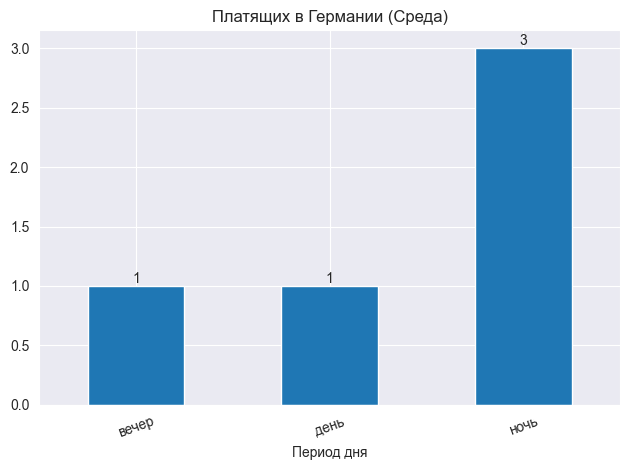

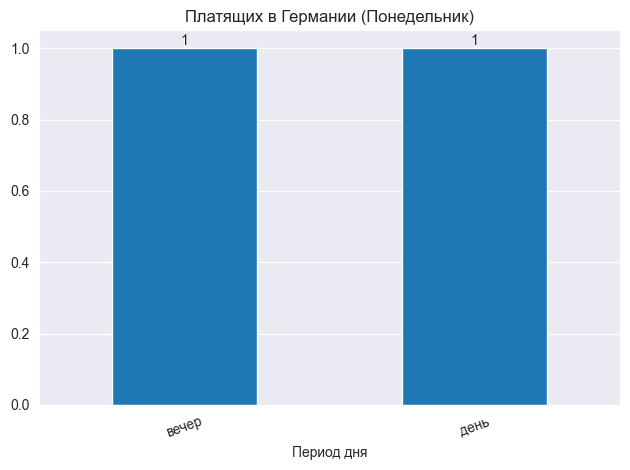

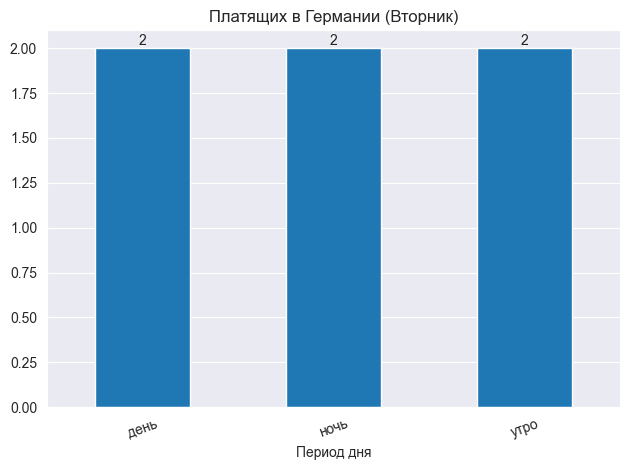

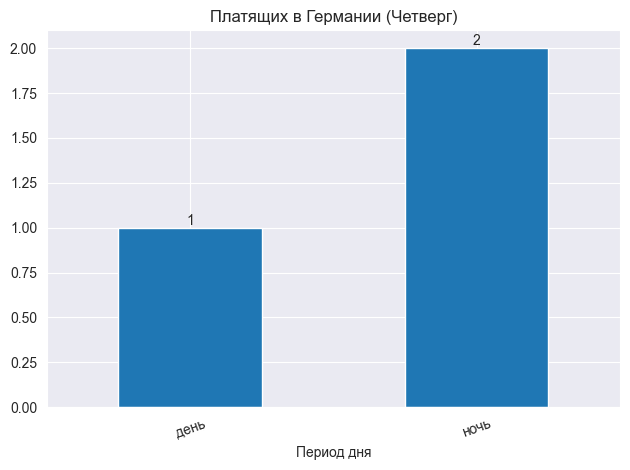

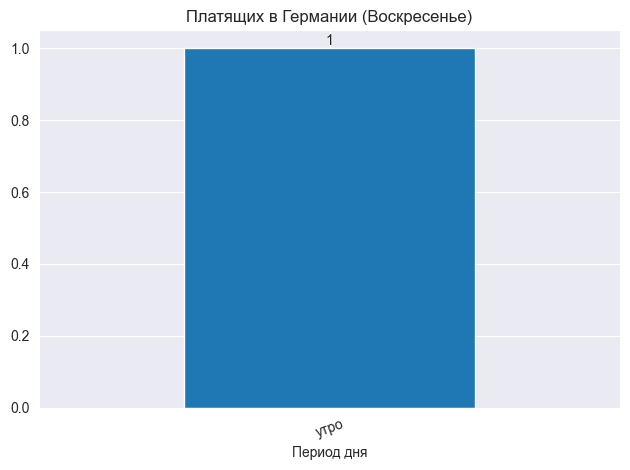

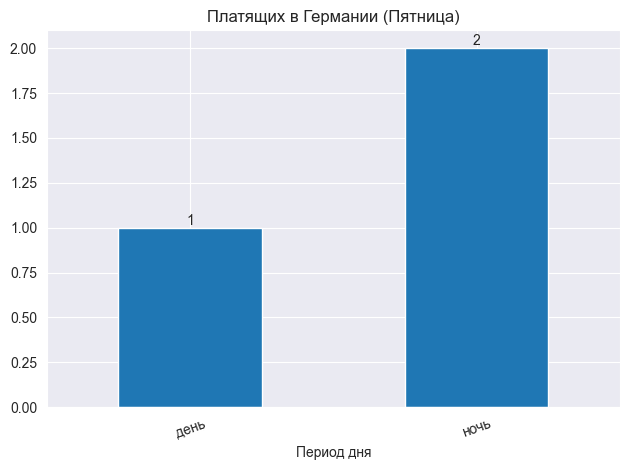

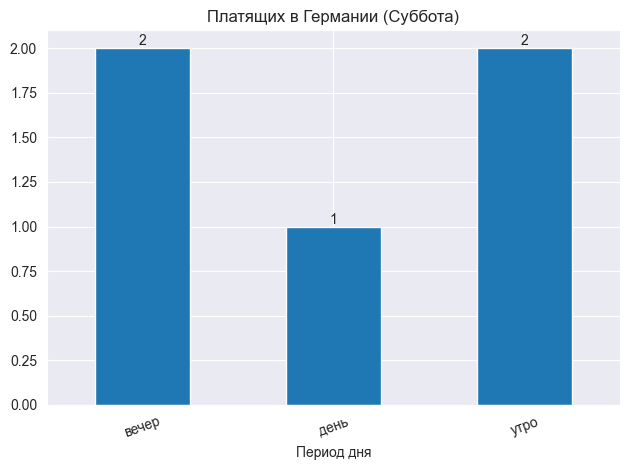

In [314]:
for day in payer_df['dayofweek'].unique():
    germany_df = payer_df[(payer_df['region'] == 'Germany') & (payer_df['dayofweek'] == day)].groupby('type_of_time')[
        'payer'].count().reset_index()

    ax = germany_df.plot(kind='bar', x='type_of_time', legend=False)
    ax.set_title(f'Платящих в Германии ({day})')
    ax.set_xlabel('Период дня')
    for cont in ax.containers:
        ax.bar_label(
            cont,
            labels=[f'{val}' for val in cont.datavalues],
        )
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Можно заметить, что в разные дни недели наблюдаются разные сезонности в покупках.

1**Нулевая гипотеза(H0): Между доходом и продолжительностью сессии нету связи**

**Альтернативная гипотеза(Ha): Количественные шкалы дохода и продолжительности сессии взаимосвязаны**


In [315]:
collection_of_correlations = {}
ana = numerical_numerical(payer_df, 'sessiondurationsec', 'revenue')
print(ana.result())

Нет значимого влияния между sessiondurationsec и revenue (p=0.2909


**Нулевая гипотеза(H0): Количество покупок в день не зависит от региона**

**Альтернативная гипотеза(Ha): Регион влияет на количество покупок в день**

In [316]:
purchase_per_day_df = payer_df.groupby(['region', 'month', 'day']).size().reset_index(name='number_of_purchases')
group_list = []
for i in payer_df.region.unique():
    group_list.append(purchase_per_day_df[(purchase_per_day_df['region'] == i)]['number_of_purchases'])
analysis = numerical_categorical(payer_df, group_list, col_name='region', target_name='количество покупок в день')
print(analysis.result())

Обнаружен значимый эффект для region на количество покупок в день(p=0.000005, метод=Kruskal-Wallis, статистика=27.41)


**Нулевая гипотеза(H0):** Нету значительной взаимосвязи между рекламным каналом и использованием промокода  

**Альтернативная гипотеза(Ha):** Есть значительная взаимосвязь между рекламным каналом и использованием промокода

In [317]:
analysis = Categorical_categorical(payer_df, 'channel', 'promo_code')
analysis.result()

'Не найдено связи между channel и promo_code так как (p=0.2398'

**Нулевая гипотеза(H0):** Нету значительной взаимосвязи между типом устройства и методом платежа  

**Альтернативная гипотеза(Ha):** Есть значительная взаимосвязь между типом устройства и методом платежа

In [318]:
analysis = Categorical_categorical(payer_df, 'device', 'payment_type')
analysis.result()

'Отклоняем нулевую гипотезу ведь найдено влияние device на payment_type ведь (p-value=0.0053)'

Теперь проанализируем графически с помощью круговых диаграмм

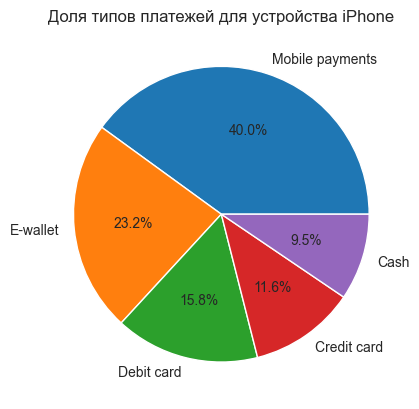

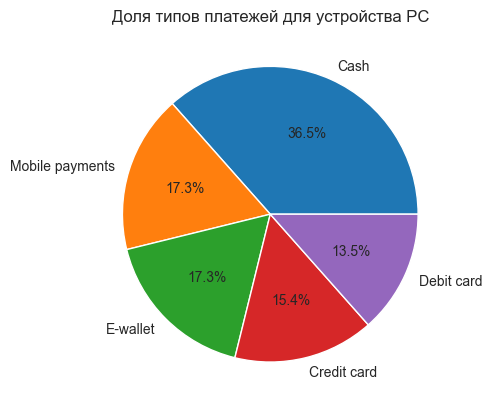

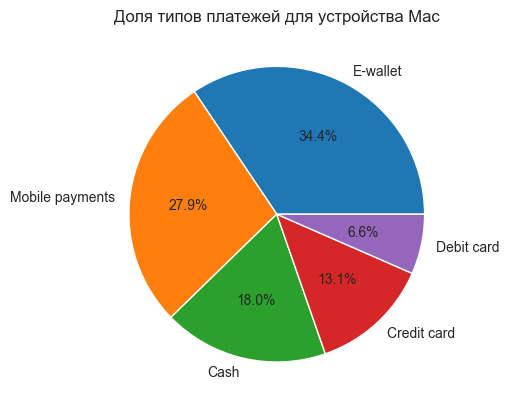

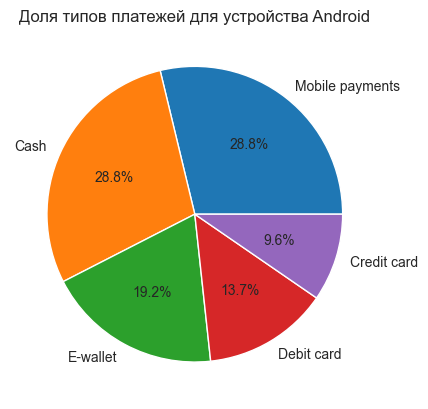

In [319]:
for ptype1 in df['device'].unique():
    if pd.isna(ptype1):
        continue
    labels = df[df['device'] == ptype1]['payment_type'].value_counts().index
    fig = plt.figure()
    plt.pie(df[df['device'] == ptype1]['payment_type'].value_counts(), labels=labels, autopct='%1.1f%%')
    plt.title(f'Доля типов платежей для устройства {ptype1}')
    plt.show()

Как мы и видим и вправду метод платежа зависит от устройства. Не удивительно, что пользователи мобильных устройств предпочитают пользоваться мобильным платежом, в то время как пользователи PC и MAC предпочитают пользоваться кэшом либо электронным кошельком. Одно остается точным, что платежи кредитными и дебетовыми картами самые редкие из вех типов. Причиной этому может быть неудобность системы или нужда в заполнении данных от карточки. Можно внедрить систему защищенного сохранения данных карт, если она отсутствует.

**Нулевая гипотеза(H0):** Нету значимой взаимосвязи между рекламным каналом и конверсией пользователя в платящего

**Альтернативная гипотеза(Ha):** Есть значимая взаимосвязь между рекламным каналом и конверсией пользователя в платящего

In [320]:
group_list = []
for i in payer_df.device.unique():
    group_list.append(payer_df[(payer_df['device'] == i)]['sessiondurationsec'])
analysis = numerical_categorical(payer_df, group_list, col_name='device', target_name='sessiondurationsec')
print(analysis.result())

Значимый эффект для device на sessiondurationsec не обнаружен (p=0.411646, метод=Kruskal-Wallis)


**Нулевая гипотеза(H0):** Нету значимой взаимосвязи между рекламным каналом и конверсией пользователя в платящего

**Альтернативная гипотеза(Ha):** Есть значимая взаимосвязь между рекламным каналом и конверсией пользователя в платящего

In [321]:
analysis = Categorical_categorical(df, 'channel', 'payer')
analysis.result()

'Не найдено связи между channel и payer так как (p=0.6845'

**Нулевая гипотеза(H0):** Нету значимой взаимосвязи между временем суток и средним чеком с разбивкой по регионам

**Альтернативная гипотеза(Ha):** Есть значимая взаимосвязь между временем суток и средним с разбивкой по регионам

In [322]:
group_list = []
for i in payer_df.region.unique():
    for j in payer_df.payment_type.unique():
        group_list.append(payer_df[(payer_df['region'] == i) & (payer_df['payment_type'] == j)]['revenue'])
    analysis = numerical_categorical(payer_df, group_list, col_name='type_of_time',
                                     target_name='количество покупок в день')
    print(i)
    print('-' * 50)
    print(analysis.result())
    print('-' * 50)
    group_list = []

United States
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.314224, метод=Kruskal-Wallis)
--------------------------------------------------
Germany
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.230134, метод=Kruskal-Wallis)
--------------------------------------------------
France
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.405880, метод=Kruskal-Wallis)
--------------------------------------------------
United kingdom
--------------------------------------------------
Значимый эффект для type_of_time на количество покупок в день не обнаружен (p=0.920730, метод=Kruskal-Wallis)
--------------------------------------------------


**Нулевая гипотеза(H0):** Нету значимой взаимосвязи между рекламным каналом и использованием промокода

**Альтернативная гипотеза(Ha):** Есть значимая взаимосвязь между рекламным каналом и использованием промокода

In [323]:
analysis = Categorical_categorical(payer_df, 'channel', 'promo_code')
analysis.result()

'Не найдено связи между channel и promo_code так как (p=0.2398'

**Нулевая гипотеза(H0):** Нету значимой взаимосвязи между днем недели и средней продолжительности сессии с разбивкой по регионам

**Альтернативная гипотеза(Ha):** Есть значимая взаимосвязь между между днем недели и средней продолжительности сессии с разбивкой по регионам

In [324]:
group_list = []
for i in payer_df.region.unique():
    for j in payer_df.dayofweek.unique():
        group_list.append(payer_df[(payer_df['region'] == i) & (payer_df['dayofweek'] == j)]['sessiondurationsec'])
    analysis = numerical_categorical(payer_df, group_list, col_name='day_of_week', target_name='sessiondurationsec')
    print(i)
    print('-' * 50)
    print(analysis.result())
    print('-' * 50)
    group_list = []

United States
--------------------------------------------------
Обнаружен значимый эффект для day_of_week на sessiondurationsec(p=0.009526, метод=Kruskal-Wallis, статистика=16.93)
--------------------------------------------------
Germany
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние day_of_week на sessiondurationsec
--------------------------------------------------
France
--------------------------------------------------
Недостаточно данных в группах чтобы проверить влияние day_of_week на sessiondurationsec
--------------------------------------------------
United kingdom
--------------------------------------------------
Значимый эффект для day_of_week на sessiondurationsec не обнаружен (p=0.463667, метод=ANOVA)
--------------------------------------------------


1 день недели в США


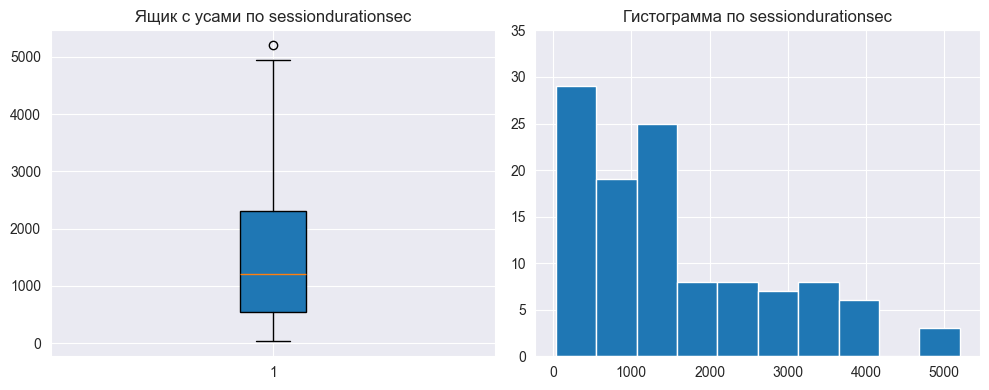

2 день недели в США


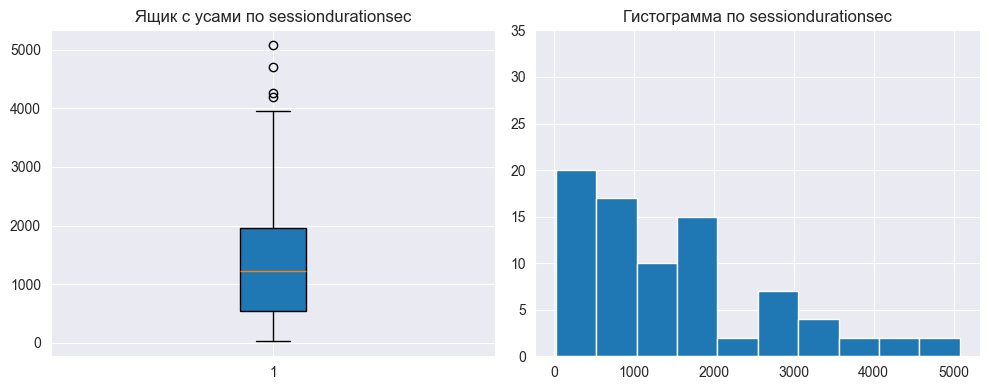

3 день недели в США


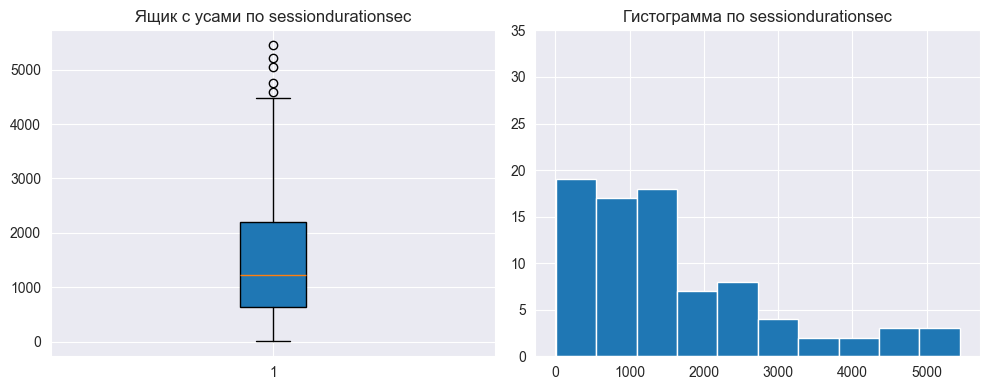

4 день недели в США


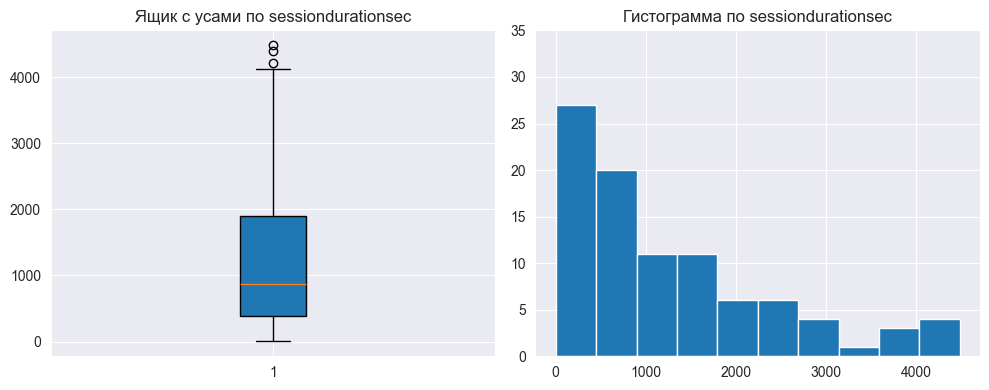

5 день недели в США


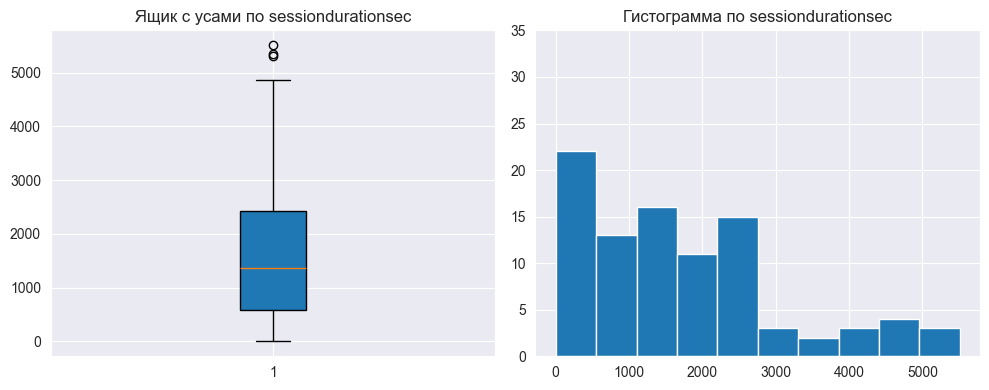

6 день недели в США


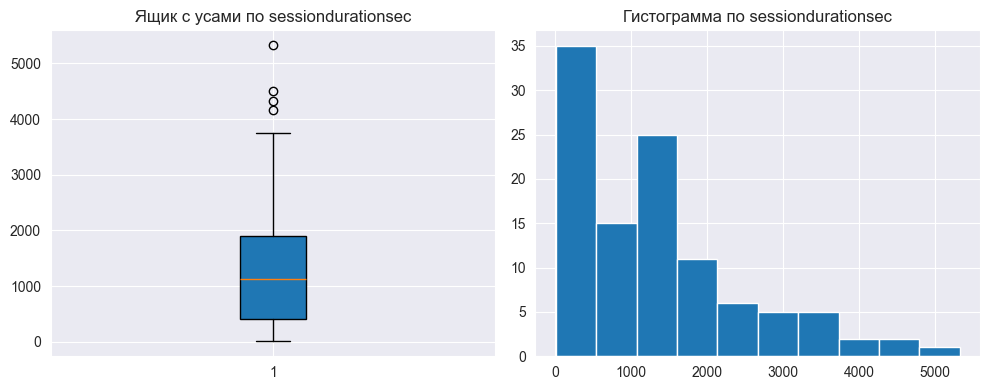

7 день недели в США


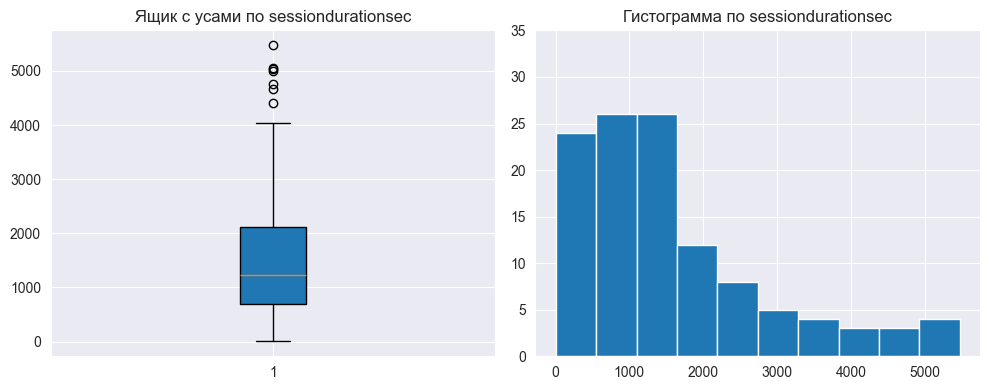

In [325]:
def draw_box_hist_usa(df, col):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

    # Ящик с усами слева
    ax1.boxplot(df[col], patch_artist=True)
    ax1.set_title(f'Ящик с усами по {col}')
    ax1.set_ylabel('')

    # Гистограмма справа
    ax2.hist(df[col])
    ax2.set_title(f'Гистограмма по {col}')
    ax2.set_yticks([0, 5, 10, 15, 20, 25, 30, 35])  # Чтобы зафиксировать величины

    plt.show()


for i in range(7):
    print(f"{i + 1} день недели в США")
    draw_box_hist_usa(df[(df['region'] == 'United States') & (df['day'] == i + 1)], 'sessiondurationsec')

Чисто из графиков тяжело увидеть тренд сезонности в США, поэтому стоит отдельно посчитать среднюю продолжительность по каждому дню недели

In [326]:
payer_df[payer_df['region'] == 'United States'].groupby(['dayofweek'])['sessiondurationsec'].mean()

dayofweek
Воскресенье    1678.100000
Вторник        2235.045454
Понедельник    1444.666667
Пятница        1785.343750
Среда          1607.607143
Суббота        1264.433333
Четверг         864.925926
Name: sessiondurationsec, dtype: float64

In [327]:
(
    payer_df[payer_df['region'] == 'United States']
    .groupby('dayofweek')['sessiondurationsec']
    .mean()
    .div(60)  # Конвертация секунд в минуты
    .round(1)  # Округление до 1 знака
    .sort_values(ascending=False)  # Сортировка по убыванию
    .reset_index()
    .rename(columns={
        'dayofweek': 'День недели',
        'sessiondurationsec': 'Средняя продолжительность (мин)'
    })
    .style
    .set_properties(**{
        'background-color': '#f8f9fa',
        'color': '#212529',
        'border': '1px solid #dee2e6',
        'font-family': 'Arial, sans-serif'
    })
    .set_properties(subset=['День недели'], **{
        'text-align': 'center'
    })
    .set_properties(subset=['Средняя продолжительность (мин)'], **{
        'text-align': 'right'
    })
    .format({'Средняя продолжительность (мин)': '{:.1f}'})
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#495057'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-transform', 'uppercase'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [('padding', '8px 12px')]
        }
    ])
    .set_caption(
        '<h4 style="text-align:center;margin-bottom:12px;color:#495057">'
        'Средняя продолжительность сессий по дням недели (США)</h4>'
    )
)

,День недели,Средняя продолжительность (мин)
0,Вторник,37.3
1,Пятница,29.8
2,Воскресенье,28.0
3,Среда,26.8
4,Понедельник,24.1
5,Суббота,21.1
6,Четверг,14.4


Теперь можно увидеть , что США демонстрируют по средней продолжительности сессий в воскресенье вторник и пятницу.  
(Решили также отметить воскресенье ведь довольно больше число посещений в целом из гистограммы)

**Рекомендации:**  
 Повышать конверсию в платежи в "пиковые" дни по продолжительности сессии для региона США, путем запуска специальных акций и скидок (вс, вт, пт):
 
 Стимулировать спрос в "слабые" дни (сб, чт):
Ввести ограниченные по времени предложения 
_____________________________________________________________________________________________________________________________________________


**Нулевая гипотеза(H0):** Нету значимой взаимосвязи между регионом и рекламным каналом через который проходят пользователи

**Альтернативная гипотеза(Ha):** Есть значимая взаимосвязь между регионом и рекламным каналом через который проходят пользователи

In [328]:
analysis = Categorical_categorical(df, 'region', 'channel')
analysis.result()

'Отклоняем нулевую гипотезу ведь найдено влияние region на channel ведь (p-value=0.0000)'

In [329]:
sum(payer_df.groupby('month')['revenue'].sum()) / len(payer_df.groupby('month')['revenue'].sum())

260119.83333333334

In [330]:
payer_df.head(5)

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,final_rev,payer,type_of_time,dayofweek
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.0,2019-05-01,May,1,0,2019-05-01 00:06:40,9999.0,Mobile payments,No,9999.0,1,ночь,Среда
20,771147371911,United States,Android,organic,2019-05-06 15:49:16,2019-05-06 15:53:16,240.0,2019-05-06,May,6,15,2019-05-06 15:49:16,4999.0,Mobile payments,No,4999.0,1,день,Понедельник
28,245941309860,Germany,Mac,organic,2019-05-07 12:00:49,2019-05-07 13:10:26,4177.0,2019-05-07,May,7,13,2019-05-07 12:01:43,4999.0,Mobile payments,Yes,4499.1,1,день,Вторник
33,25672200561,United States,Android,organic,2019-05-09 16:40:44,2019-05-09 16:41:31,47.0,2019-05-09,May,9,16,2019-05-09 16:40:44,4999.0,Debit card,Yes,4499.1,1,день,Четверг
34,241867611399,United States,PC,социальные сети,2019-05-09 09:23:22,2019-05-09 09:28:28,306.0,2019-05-09,May,9,9,2019-05-09 09:23:24,4999.0,Mobile payments,No,4999.0,1,утро,Четверг


Так как мы заранее определи наивысшую активность покупок в ночное время, мы решили отдельно рассмотреть датасет с покупками ночью

**Нулевая гипотеза (H0):** При покупках в ночное время, средний чек не имеет значимой зависимости от рекламного канала

**Альтенативная гипотеза:** При покупках в ночное время, средний чек имееют значимую зависимость от рекламного канала

In [331]:
group_list = []
df_night = payer_df[payer_df['type_of_time'] == 'ночь']
for i in df_night.channel.unique():
    if i != 'email-рассылки':
        group_list.append(df_night[df_night['channel'] == i]['revenue'])
analysis = numerical_categorical(df_night, group_list, col_name='channel', target_name='среднюю выручку')
print(analysis.result())

Значимый эффект для channel на среднюю выручку не обнаружен (p=0.270596, метод=Kruskal-Wallis)


**Нулевая гипотеза(H0):** При покупках в ночное время, средний чек не имеет значимой зависимости от устройства

**Альтенативная гипотеза:** При покупках в ночное время, средний чек имееют значимую зависимость от устройства

In [332]:
group_list = []
df_night = payer_df[payer_df['type_of_time'] == 'ночь']
for i in df_night.device.unique():
    group_list.append(df_night[df_night['device'] == i]['revenue'])
analysis = numerical_categorical(df_night, group_list, col_name='channel', target_name='среднюю выручку')
print(analysis.result())

Значимый эффект для channel на среднюю выручку не обнаружен (p=0.721581, метод=Kruskal-Wallis)


# **Построение модели (Random Forest)**

In [337]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # Если нужна линейная регрессия
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor  # Наш выбор в данном случае


def regression_model(df, columns, t_size=0.15, n_est=10):
    # Определяем категориальные и числовые колонки
    categorical_cols = ['region', 'device', 'channel', 'month', 'day', 'type_of_time', 'payment_type']
    numerical_cols = ['sessiondurationsec']

    # Фильтруем выбранные колонки по типу
    categorical_X = [col for col in columns if col in categorical_cols]
    numerical_X = [col for col in columns if col in numerical_cols]

    # Удаляем строки с NaN в выбранных колонках и целевой переменной 'revenue'
    df_subset = df[columns + ['revenue']].dropna()

    X = df_subset[columns]
    y = df_subset['revenue']

    # Подготавливаем список для фичей
    features = []

    # Обрабатываем категориальные фичи
    if categorical_X:
        encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
        categorical_part = encoder.fit_transform(X[categorical_X])
        features.append(categorical_part.toarray())

    # Обрабатываем числовые фичи
    if numerical_X:
        scaler = StandardScaler()
        numerical_part = scaler.fit_transform(X[numerical_X])
        features.append(numerical_part)

    # Объединяем все фичи в один массив
    X_final = np.hstack(features)

    # Разделяем данные на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=t_size, random_state=42)

    # Инициализируем и обучаем модель случайного леса
    # model = LinearRegression()  # Для линейной регрессии, в нашем случае результат показывается хуже
    model = RandomForestRegressor(  # Модель Случайный лес
        n_estimators=n_est,
        max_depth=None,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Делаем предсказания
    y_pred = model.predict(X_test)

    # Считаем метрики оценки
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r_squared = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # plt.scatter(y_test, abs(y_pred-y_test))  # ДЛЯ АНАЛИЗА РАЗБРОСА ОШИБОК -> убрать теги
    # plt.title('Разброс ошибок')
    # plt.xlabel('Сумма покупки')
    # plt.ylabel('Ошибка модели')
    # plt.savefig('predict.png')
    return rmse, mae, r_squared, mape  # ДЛЯ АНАЛИЗА РАЗБРОСА ОШИБОК -> поставить тег

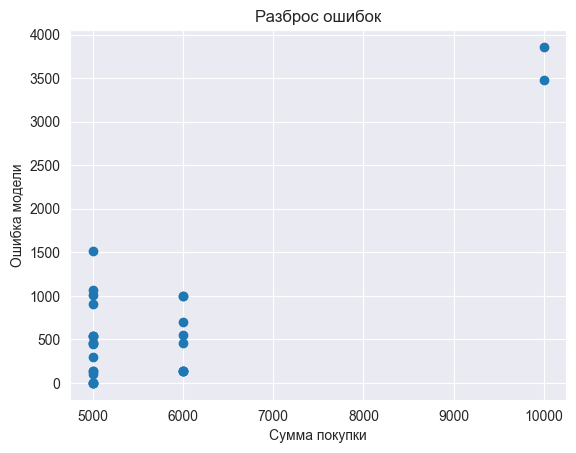

In [338]:
regression_model(payer_df, ['month', 'payment_type'], 0.1,
                 10)  # ДЛЯ АНАЛИЗА РАЗБРОСА ОШИБОК, после графика обратно вернуть теги

In [336]:
# Для лучшей генерации используем рандомные наборы фич

import random

# Виды фич
all_possible_features = [
    'region', 'device', 'channel', 'month', 'day', 'hour_of_day',
    'type_of_time', 'payment_type', 'sessiondurationsec'
]

# Разбиваем на типы
categorical_cols = ['region', 'device', 'channel', 'month', 'day', 'type_of_time', 'payment_type']
numerical_cols = ['sessiondurationsec']


def generate_random_features(k_min=1, k_max=9):
    # Создание фич
    k = random.randint(k_min, k_max)
    return random.sample(all_possible_features, k)


def is_valid_combination(features):
    # Гарантирует один количественный или несколько категориальных
    has_numerical = any(f in numerical_cols for f in features)
    return len(features) >= 1 and (has_numerical or len(features) > 1)


test_sizes = [0.1]  # Лучший вариант, можно менять
n_estim = [10]  # Лучший вариант, можно менять

# Применяем модель на разных фичах
for _ in range(999):  # Для гарантии
    random_features = generate_random_features()
    while not is_valid_combination(random_features):
        random_features = generate_random_features()
    # Проверяем по каждому размеру выборки и количеству деревьев(n_estimators)
    for size in test_sizes:
        for n_est in n_estim:
            rmse, mae, r2, mape = regression_model(payer_df, random_features, size, n_est)
            if r2 > 0.15:
                print(f"Features: {random_features}")
                print(
                    f"N_estimators: {n_est} | Test size: {size} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f} | MAPE: {mape * 100: .2f}%")
                print("-" * 50)

Features: ['device', 'sessiondurationsec', 'type_of_time']
N_estimators: 10 | Test size: 0.1 | RMSE: 1129.86 | MAE: 745.40 | R²: 0.2047 | MAPE:  11.62%
--------------------------------------------------
Features: ['device', 'payment_type', 'month', 'channel', 'sessiondurationsec', 'hour_of_day']
N_estimators: 10 | Test size: 0.1 | RMSE: 1163.08 | MAE: 755.17 | R²: 0.1573 | MAPE:  12.01%
--------------------------------------------------
Features: ['month', 'payment_type']
N_estimators: 10 | Test size: 0.1 | RMSE: 1129.54 | MAE: 681.41 | R²: 0.2052 | MAPE:  10.61%
--------------------------------------------------
Features: ['month', 'payment_type', 'hour_of_day']
N_estimators: 10 | Test size: 0.1 | RMSE: 1129.54 | MAE: 681.41 | R²: 0.2052 | MAPE:  10.61%
--------------------------------------------------
Features: ['hour_of_day', 'device', 'payment_type', 'month', 'channel', 'sessiondurationsec']
N_estimators: 10 | Test size: 0.1 | RMSE: 1163.08 | MAE: 755.17 | R²: 0.1573 | MAPE:  12.0

# ***Вывод по модели***:
Как можно заметить, при создании регрессионной модели нужно брать факторы типа покупки и месяца, так как у них лучший результат по метрикам. Выбор маленького тестового размера и низким количеством деревьев связан с низким количеством данных, что так же сказалось на результате. Лучший результат в **R^2** (0.2052) означает, что модель объясняет 20% вариации зависимой переменной, что довольно низко.

# ***Общие выводы по исследованию***

1. Около 68-70% трафика среди всех пользователей и платящих пользователей приходит из региона США. Следовательно, мы рекомендуем компании давать приоритет этому региону 
2. Пользователи в США проводят больше всего времени на сайте во вторник,пятницу, воскресенье. В четверг в среднем проводят очень мало времени на сайте Рекомендуем:
В "пиковые" дни (вт, пт, вс): усиливать рекламу дронов с помощью специальных скидок и таргетированных предложений.
В четверг: Можно завлекать пользователей дольше оставаться на сайте путем внедрения мини-игр, которые будут давать мини-скидки на дроны.
Если компания захочет продавать рекламу на своем сайте в США, стоит учитывать, что за рекламу в высокоактивные дни можно требовать более высокую ставку.
3. На сайте 'Delivery Dron' с высокой вероятностью до сих пор присутствует сбой по сохранению данных пользователей при их повторном заходе на сайт.
4. Данный пункт относится ко всем регионам кроме Англии: Контекстная реклама эффективна для привлечения пользователя на долгое пользование сайта, но больше важна прибыльность от рекламы. Эту цель хорошо выполняют социальные сети, ведь с них приходит больше всего выручки, и при этом сравнительно со всеми типами реклам имеют наибольшую конверсию. Поэтому мы рекомендуем вкладываться в основном в социальные сети для увеличения прибыльности, учитывая что социальные сети занимают среднее место по затратности, в отличии от контекстной рекламы. Нужно воспользоваться всеми соцсетями такими как реклама в сторисах в Инстаграмме, или реклама в ютубе при просмотре видео, ведь нынешние пользователи часто проводят время в соцсетях и этими методами можно захватить их внимание. 
5. Великобритания демонстрирует самые высокие показатели по среднему чеку и конверсией в платежи (лучшая среди всех регионов)
Сейчас трафик из Великобритании значительно уступает США. Поэтому нужно:
Увеличить инвестиции в привлечение пользователей (контекстная реклама, SEO, партнерские программы).
Даже небольшой рост трафика даст значительный прирост выручки благодаря высокой конверсии и среднему чеку.
UK — перспективный рынок с высокой маржинальностью. Увеличение трафика напрямую повысит прибыль. Поэтому в Великобритании мы рекомендуем вкладываться в контекстную рекламу
6. Лето — пиковый сезон продаж. Стоит запустить таргетированную рекламу для ресторанов и магазинов, так как спрос на доставку будет большим из-за жары и сезона отпусков жителей
7. Gлатежи кредитными и дебетовыми картами самые редкие из вcех типов. Причиной этому может быть неудобность системы или нужда в заполнении данных от карточки. Можно внедрить систему защищенного сохранения данных карт, если она отсутствует.
